M4 1.6mM at RT EDA

In [2]:
# plotting raw dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit, minimize
from sklearn.metrics import mean_squared_error, r2_score
import pywt
from datetime import datetime
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.stats import linregress
from scipy.stats import pearsonr
from scipy.constants import R
from matplotlib.patheffects import withStroke
from scipy.ndimage import gaussian_filter1d, uniform_filter1d
import seaborn as sns

from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

#aesthetics
# aesthetics & fonts
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
dpi = 600

def style_axes(ax, xlabel, ylabel, x_major=None, y_major=None):
    ax.set_xlabel(xlabel, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=14)
    ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
    ax.minorticks_on()
    if x_major is not None:
        ax.xaxis.set_major_locator(MultipleLocator(x_major))
    if y_major is not None:
        ax.yaxis.set_major_locator(MultipleLocator(y_major))


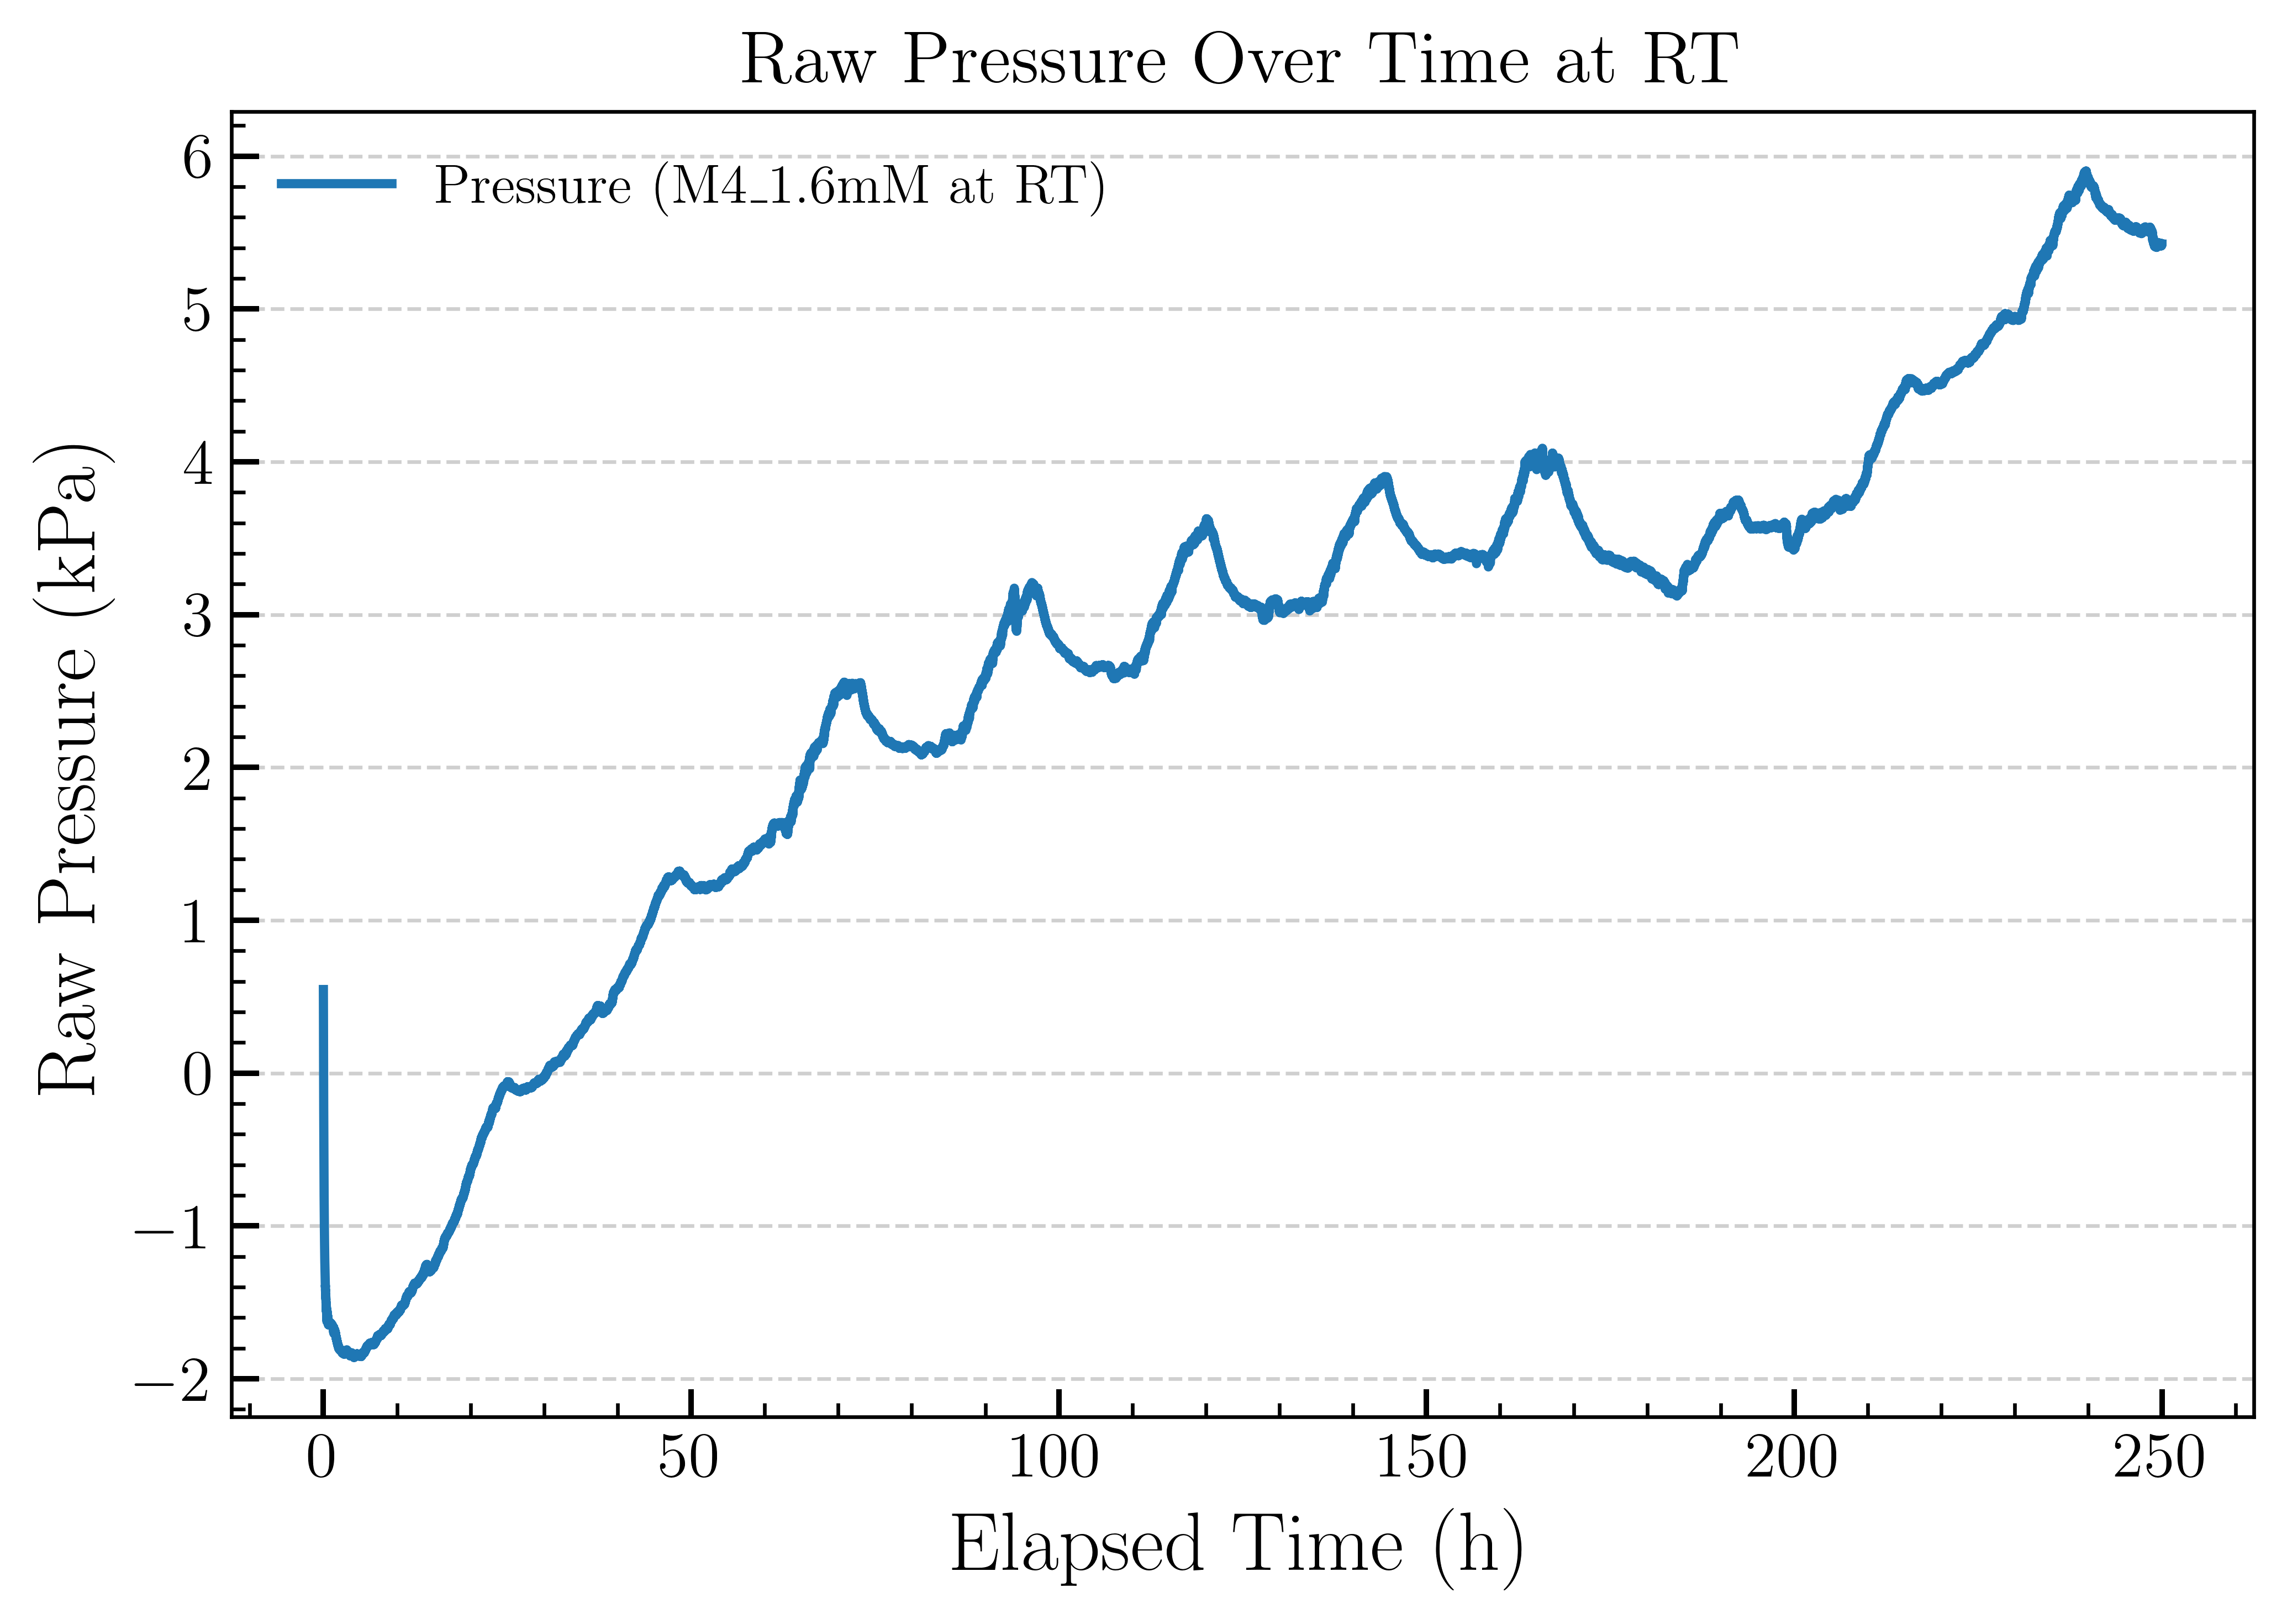

In [3]:
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\RT\Raw_data\merged_pressure_log.csv"



df = pd.read_csv(main_path)

df_filtered = df[df["Elapsed Time (hours)"] <= 250]





fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_filtered["Elapsed Time (hours)"],
         df_filtered["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_RT_raw_pressure.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [4]:
print((df["ABP2-Sch1 (kPa)"] == -2).sum())

0


df_sensor = df[df["Elapsed Time (hours)"] > 14.5]  #Got max 8 kPa with this, which will give umol greater than 9,6umol

# Testing out multiple points

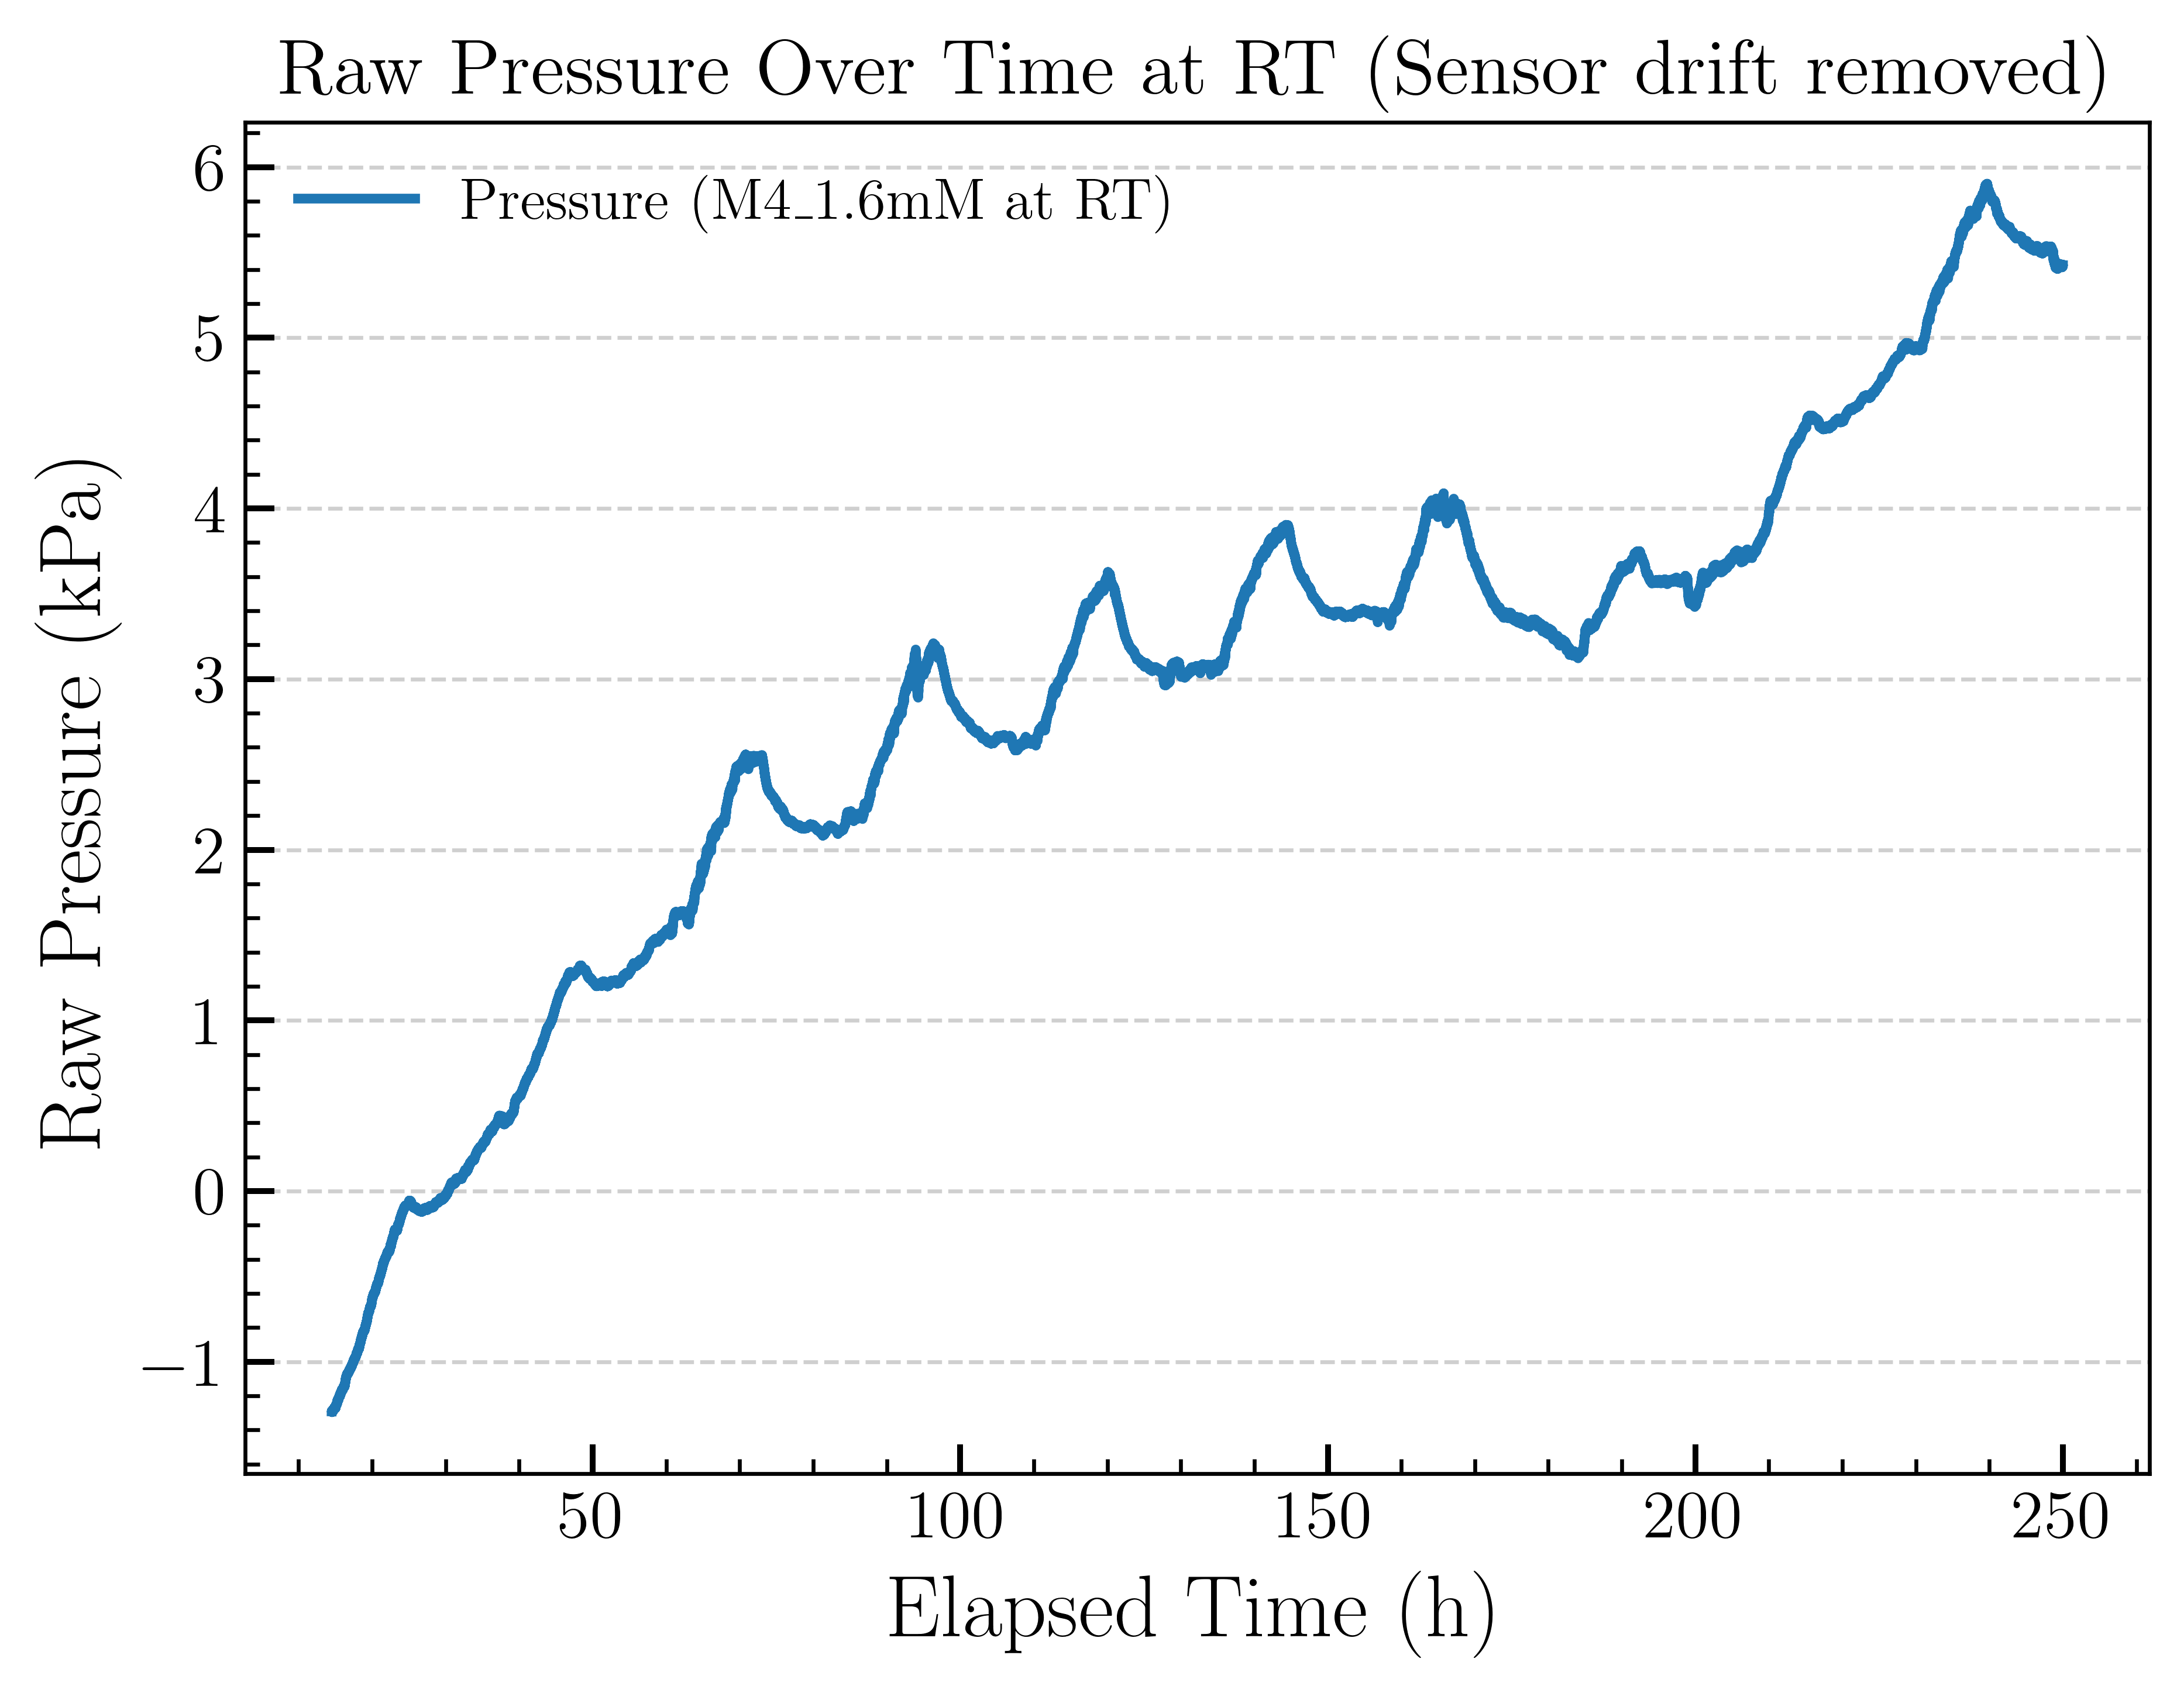

In [ ]:
df_sensor = df[(df["Elapsed Time (hours)"] > 14.5) & (df["Elapsed Time (hours)"] <= 250)].reset_index(drop=True)




fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (Sensor drift removed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")

plt.show()

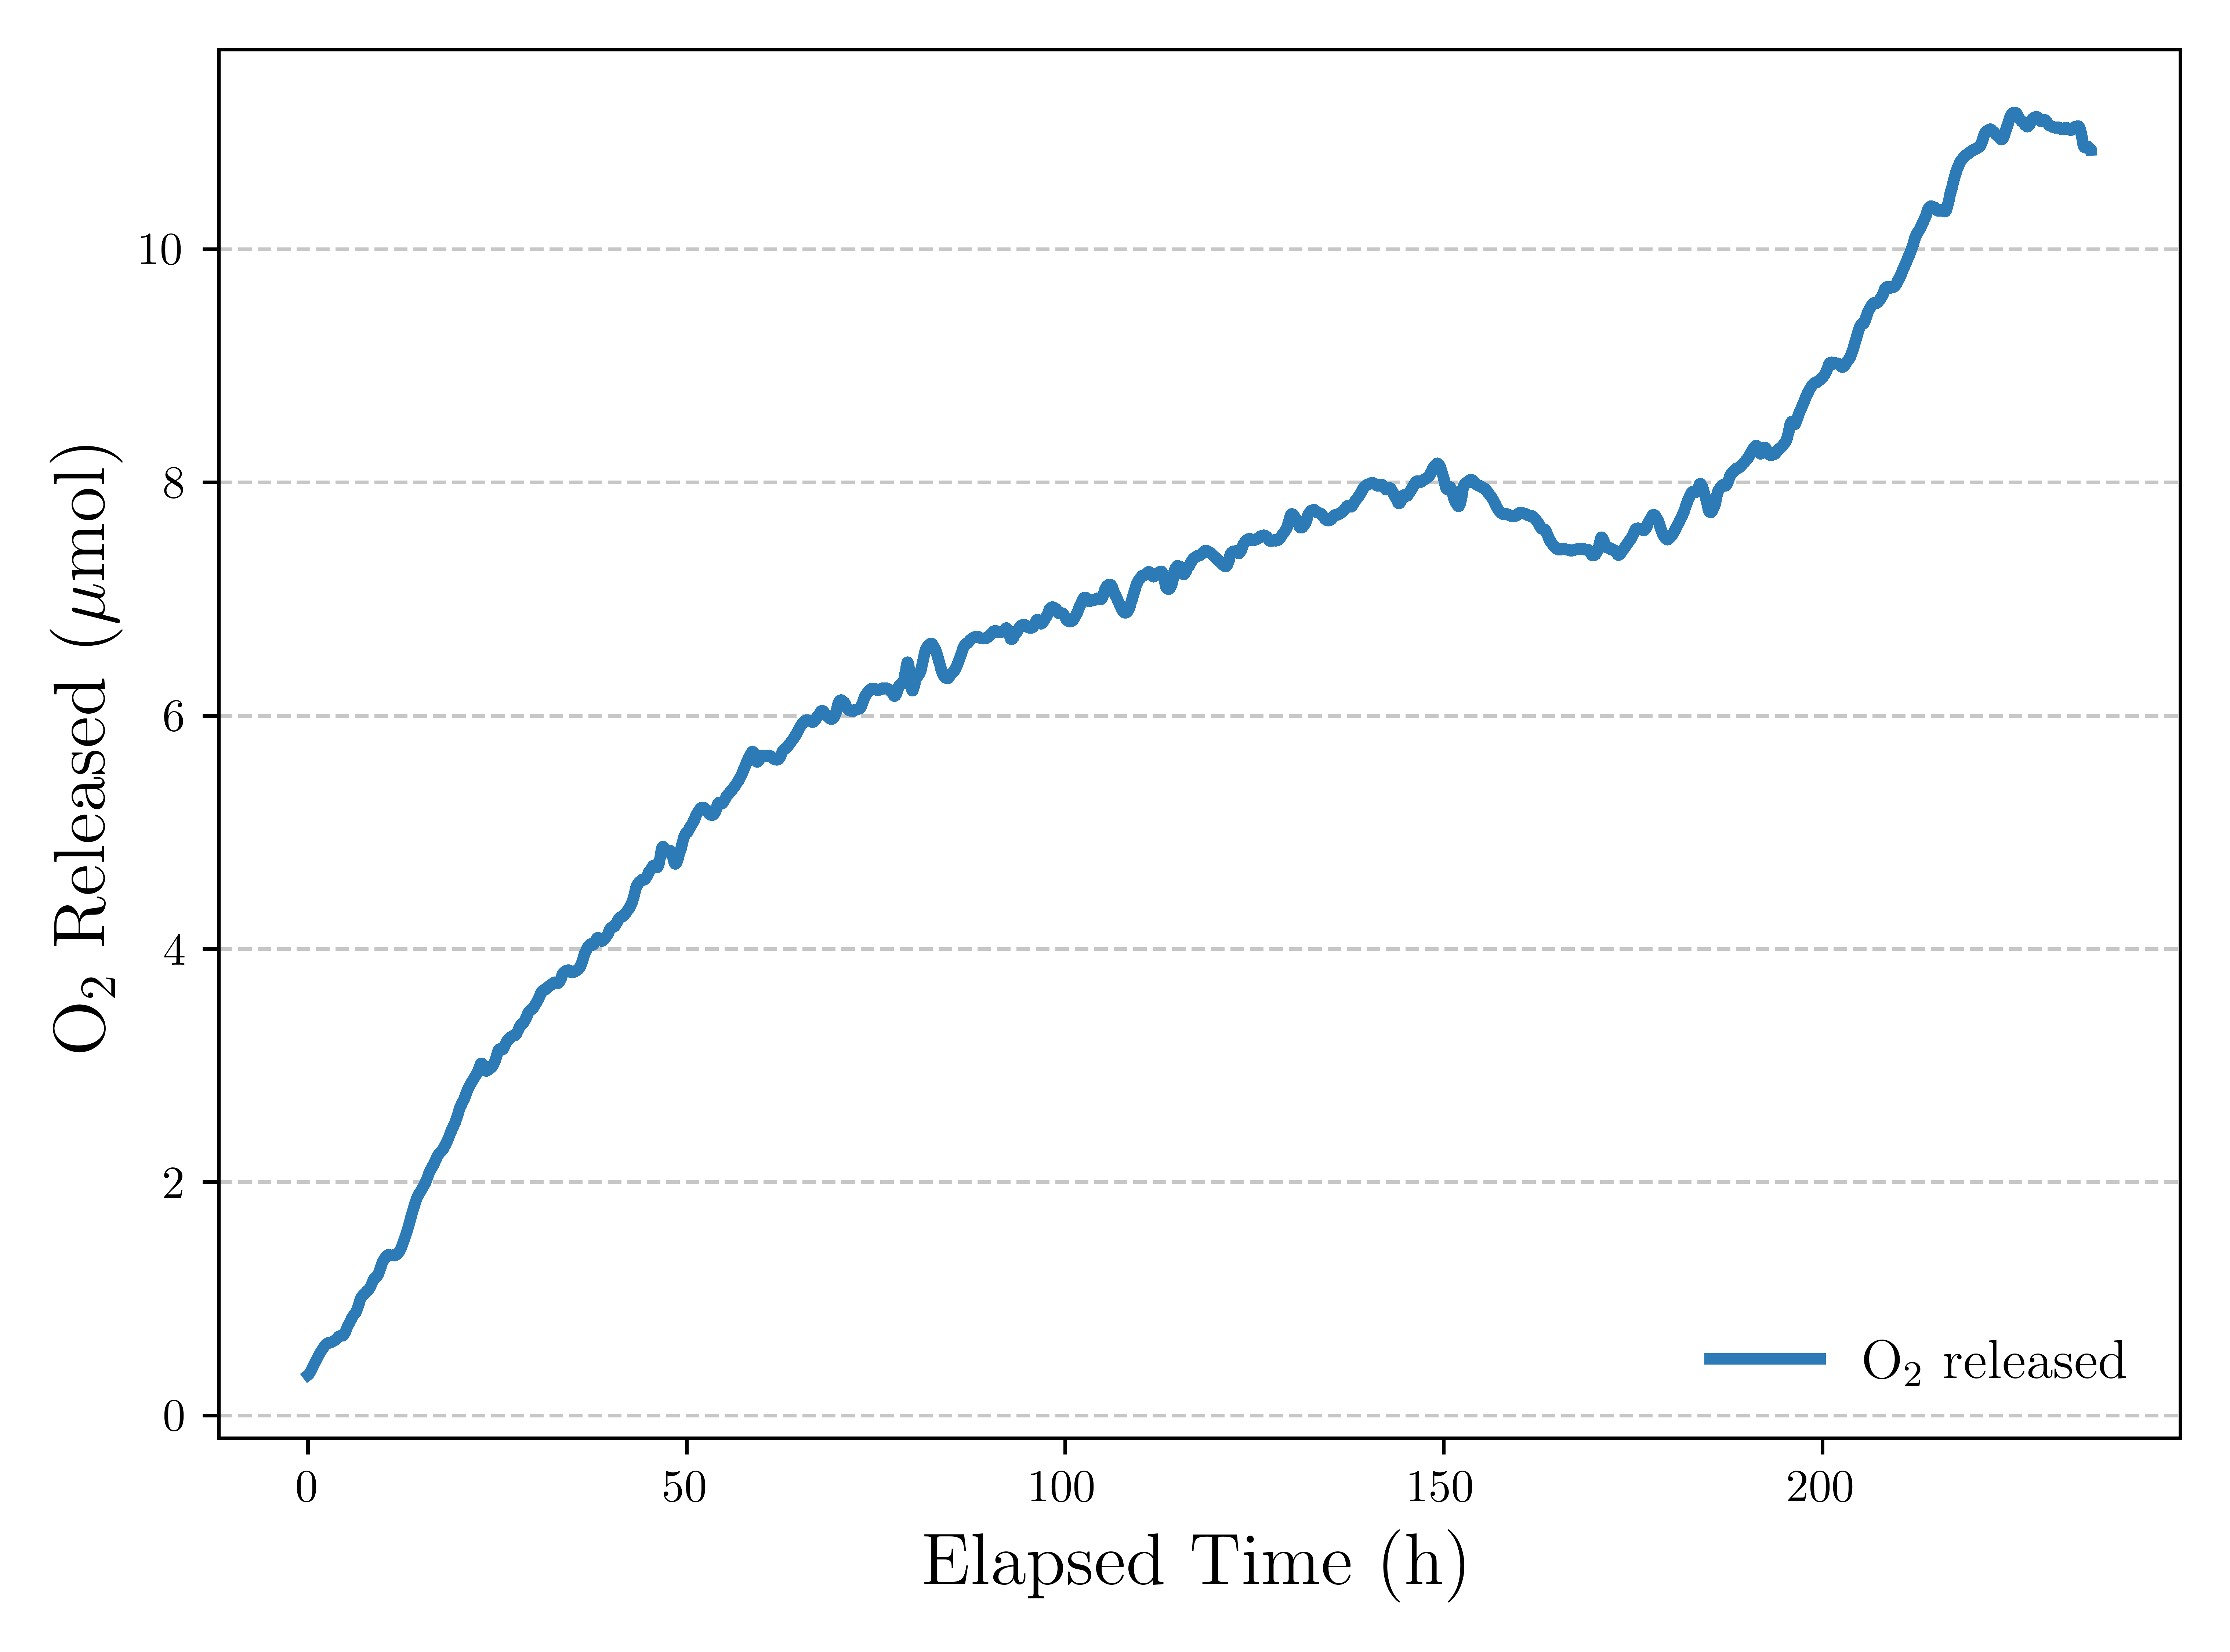

# 11.66 is unrealistic and beyond theretical max 9.6um

# 25h

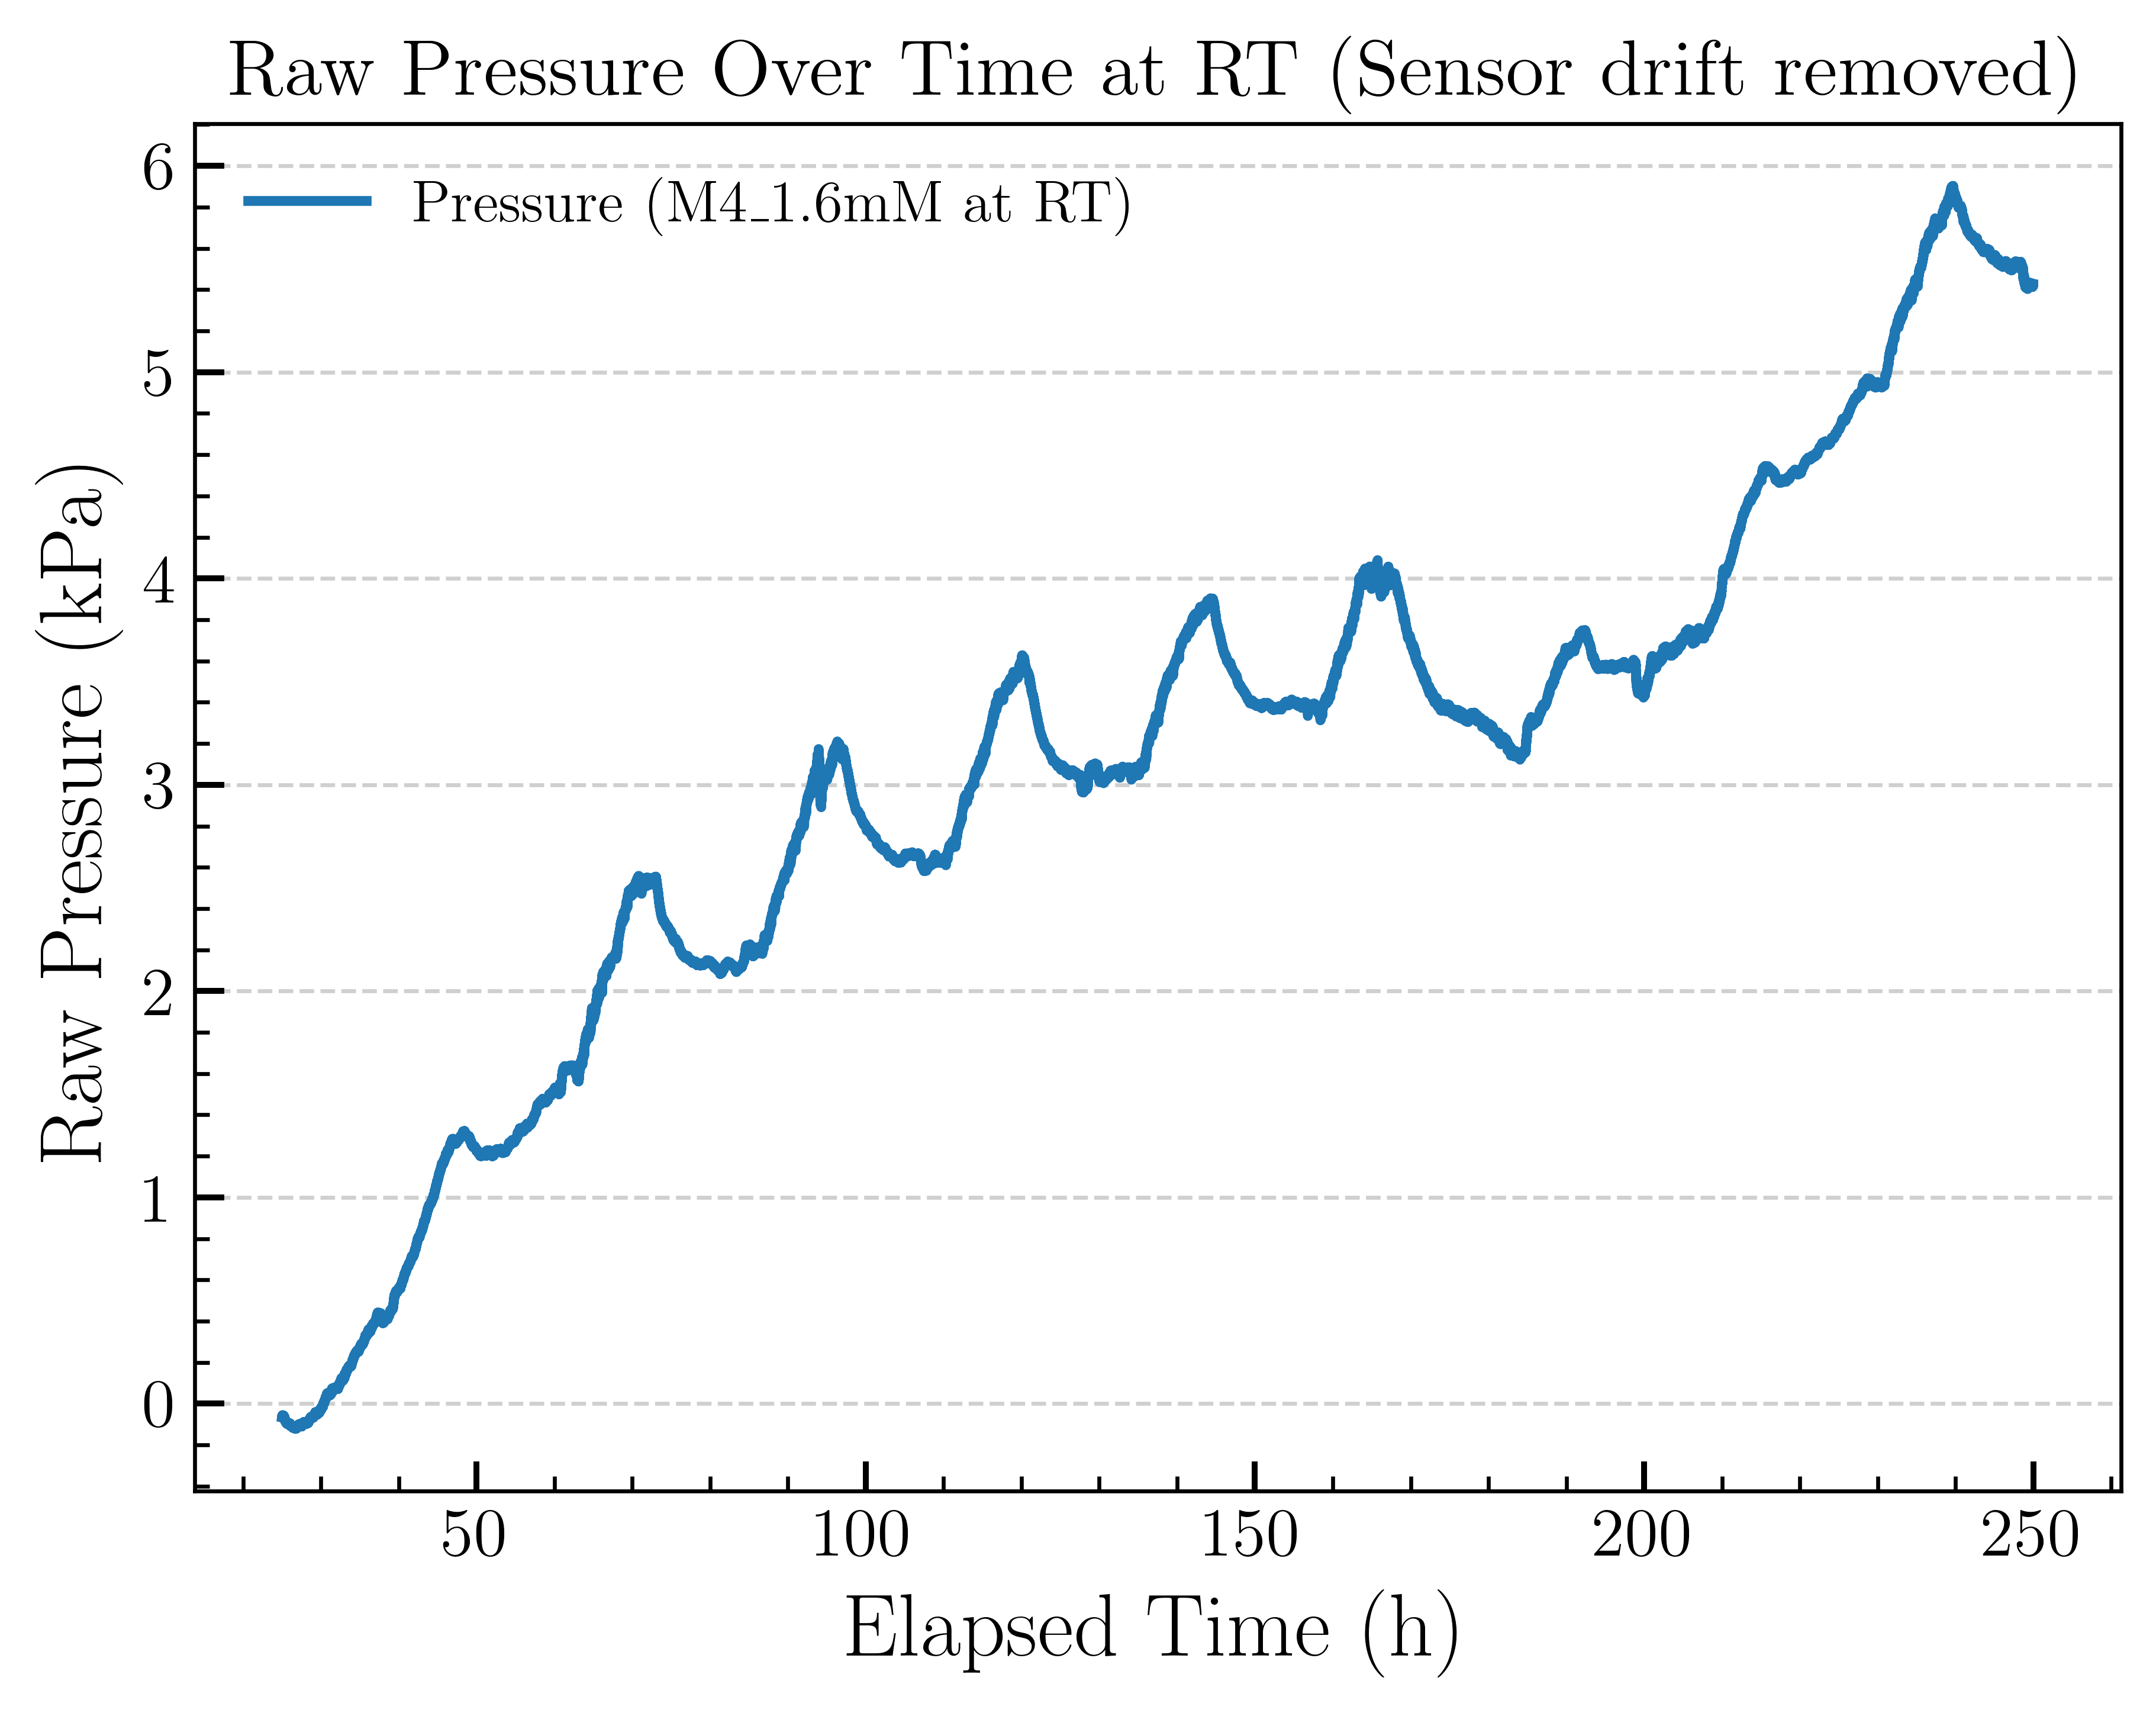

In [ ]:
df_sensor = df[(df["Elapsed Time (hours)"] > 25) & (df["Elapsed Time (hours)"] <= 250)].reset_index(drop=True)




fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (Sensor drift removed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")

plt.show()

# For 25h, 9.1uol max

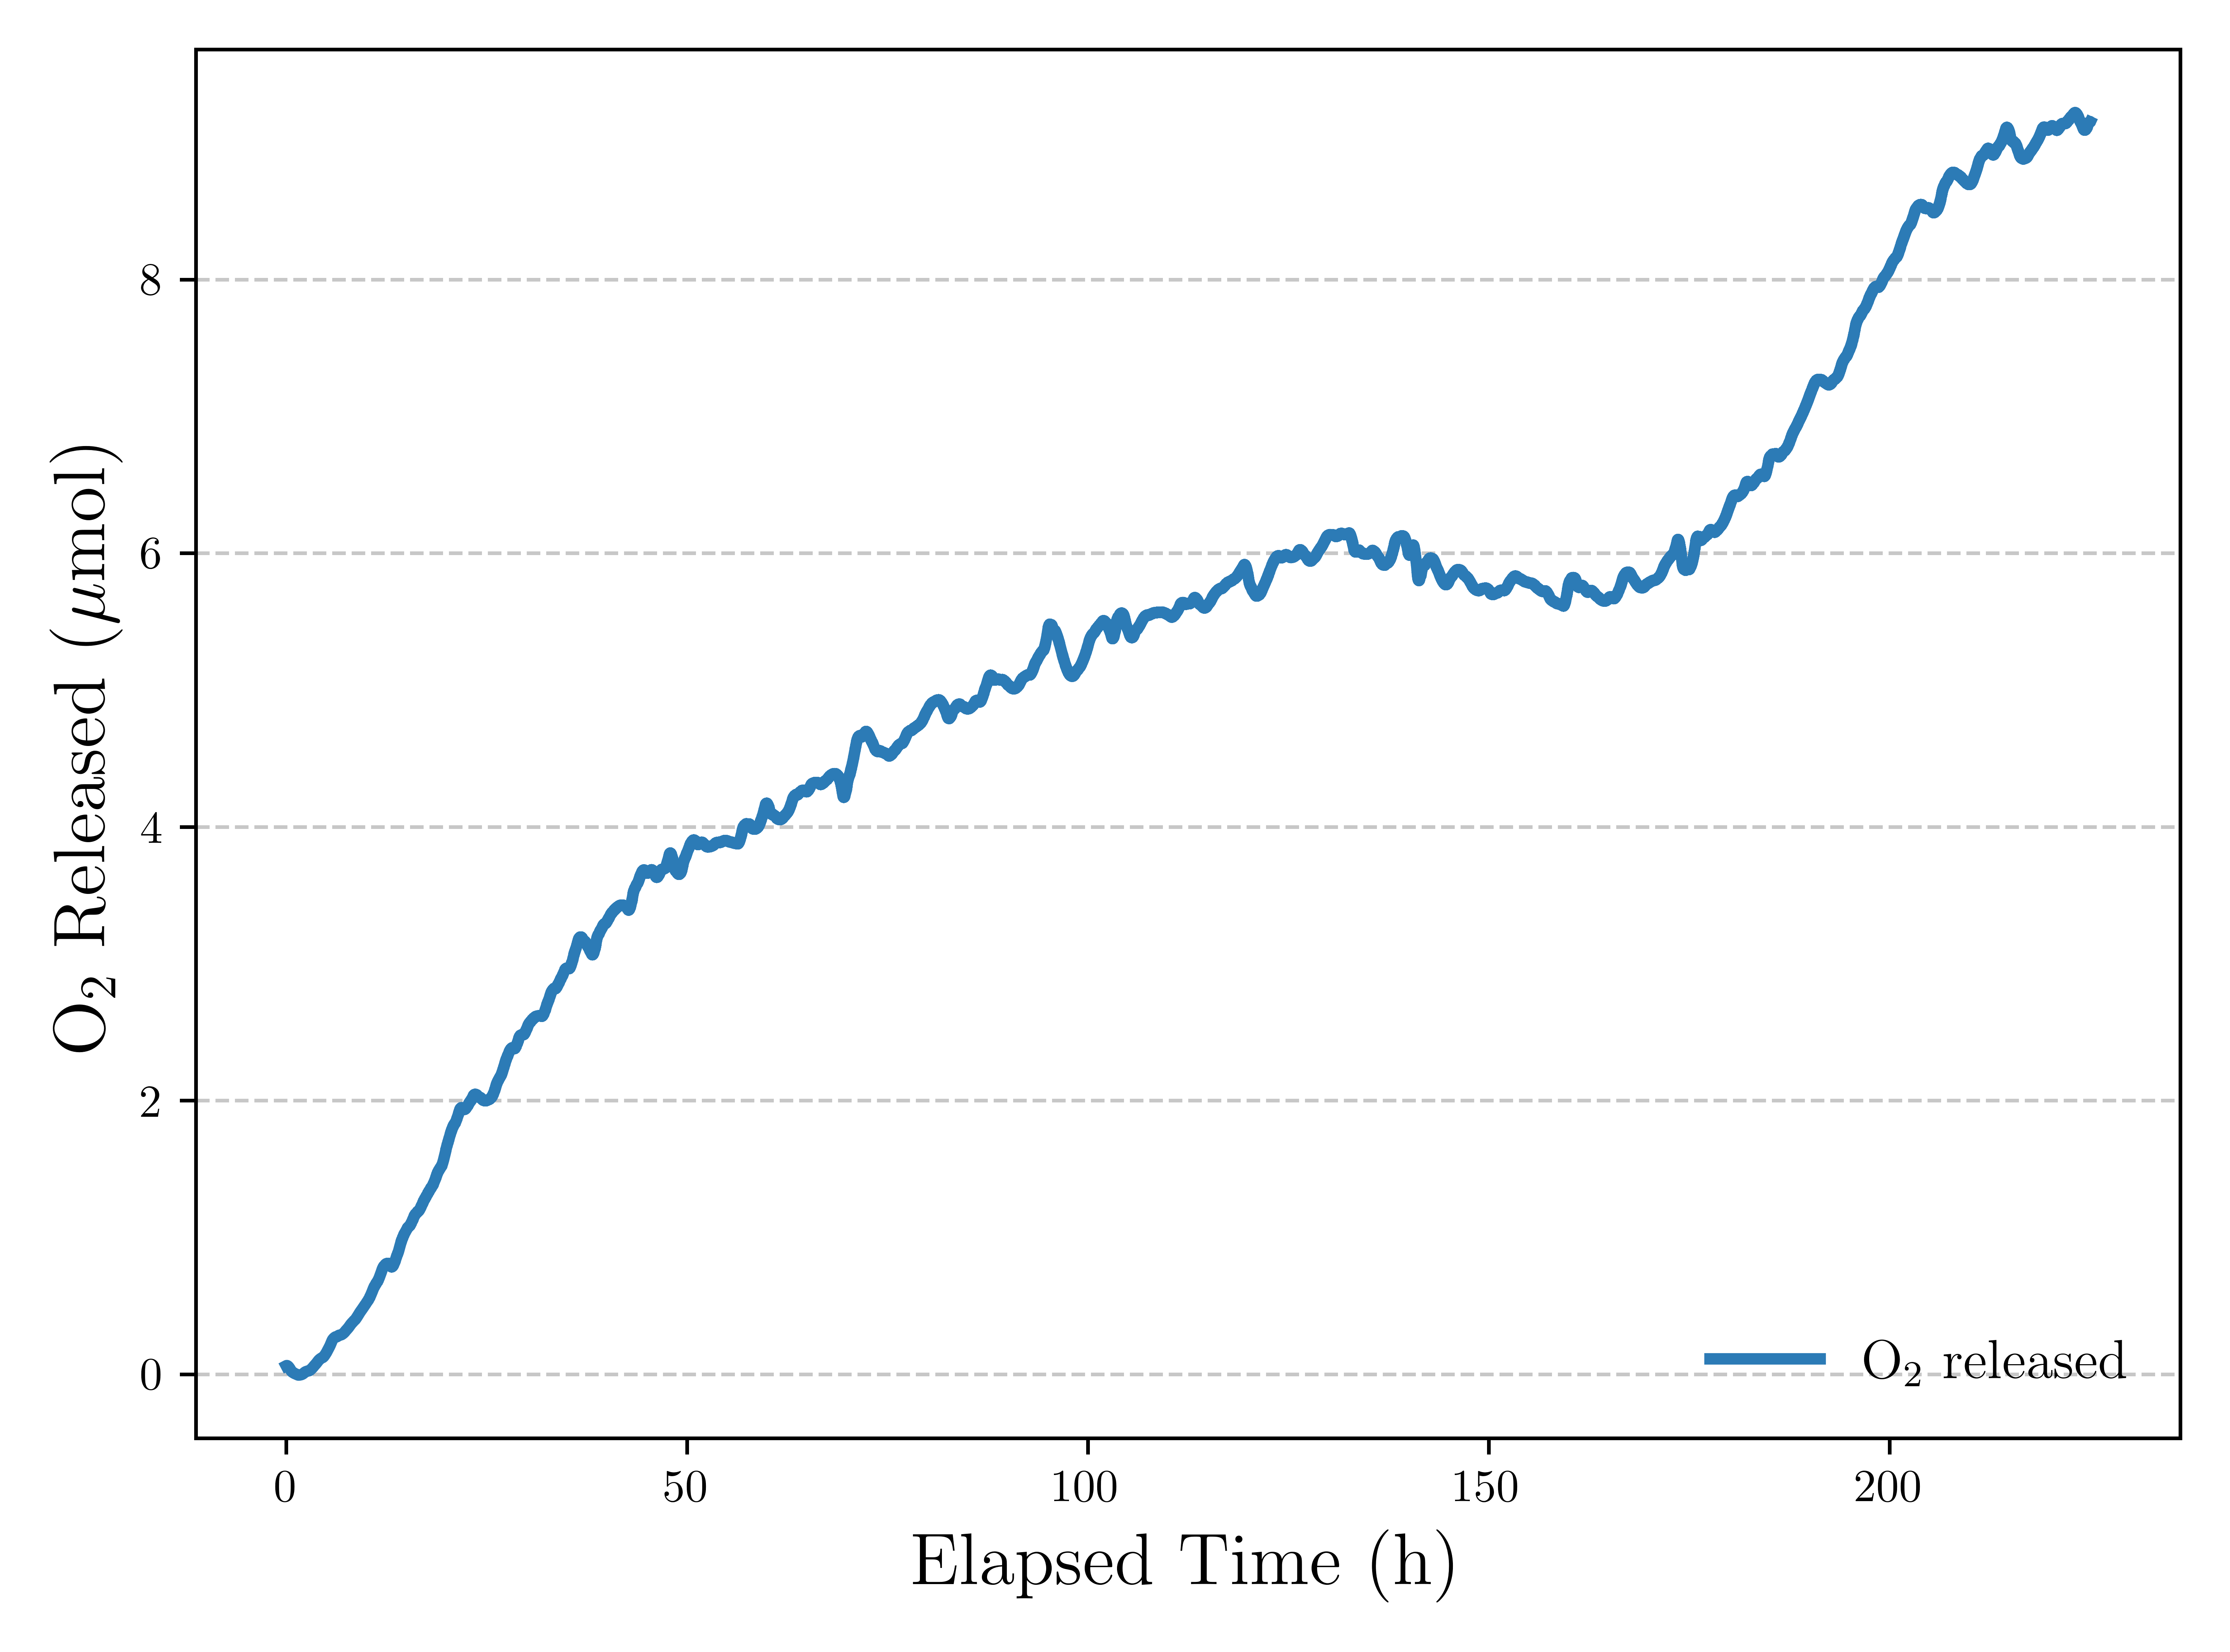

# For 35h


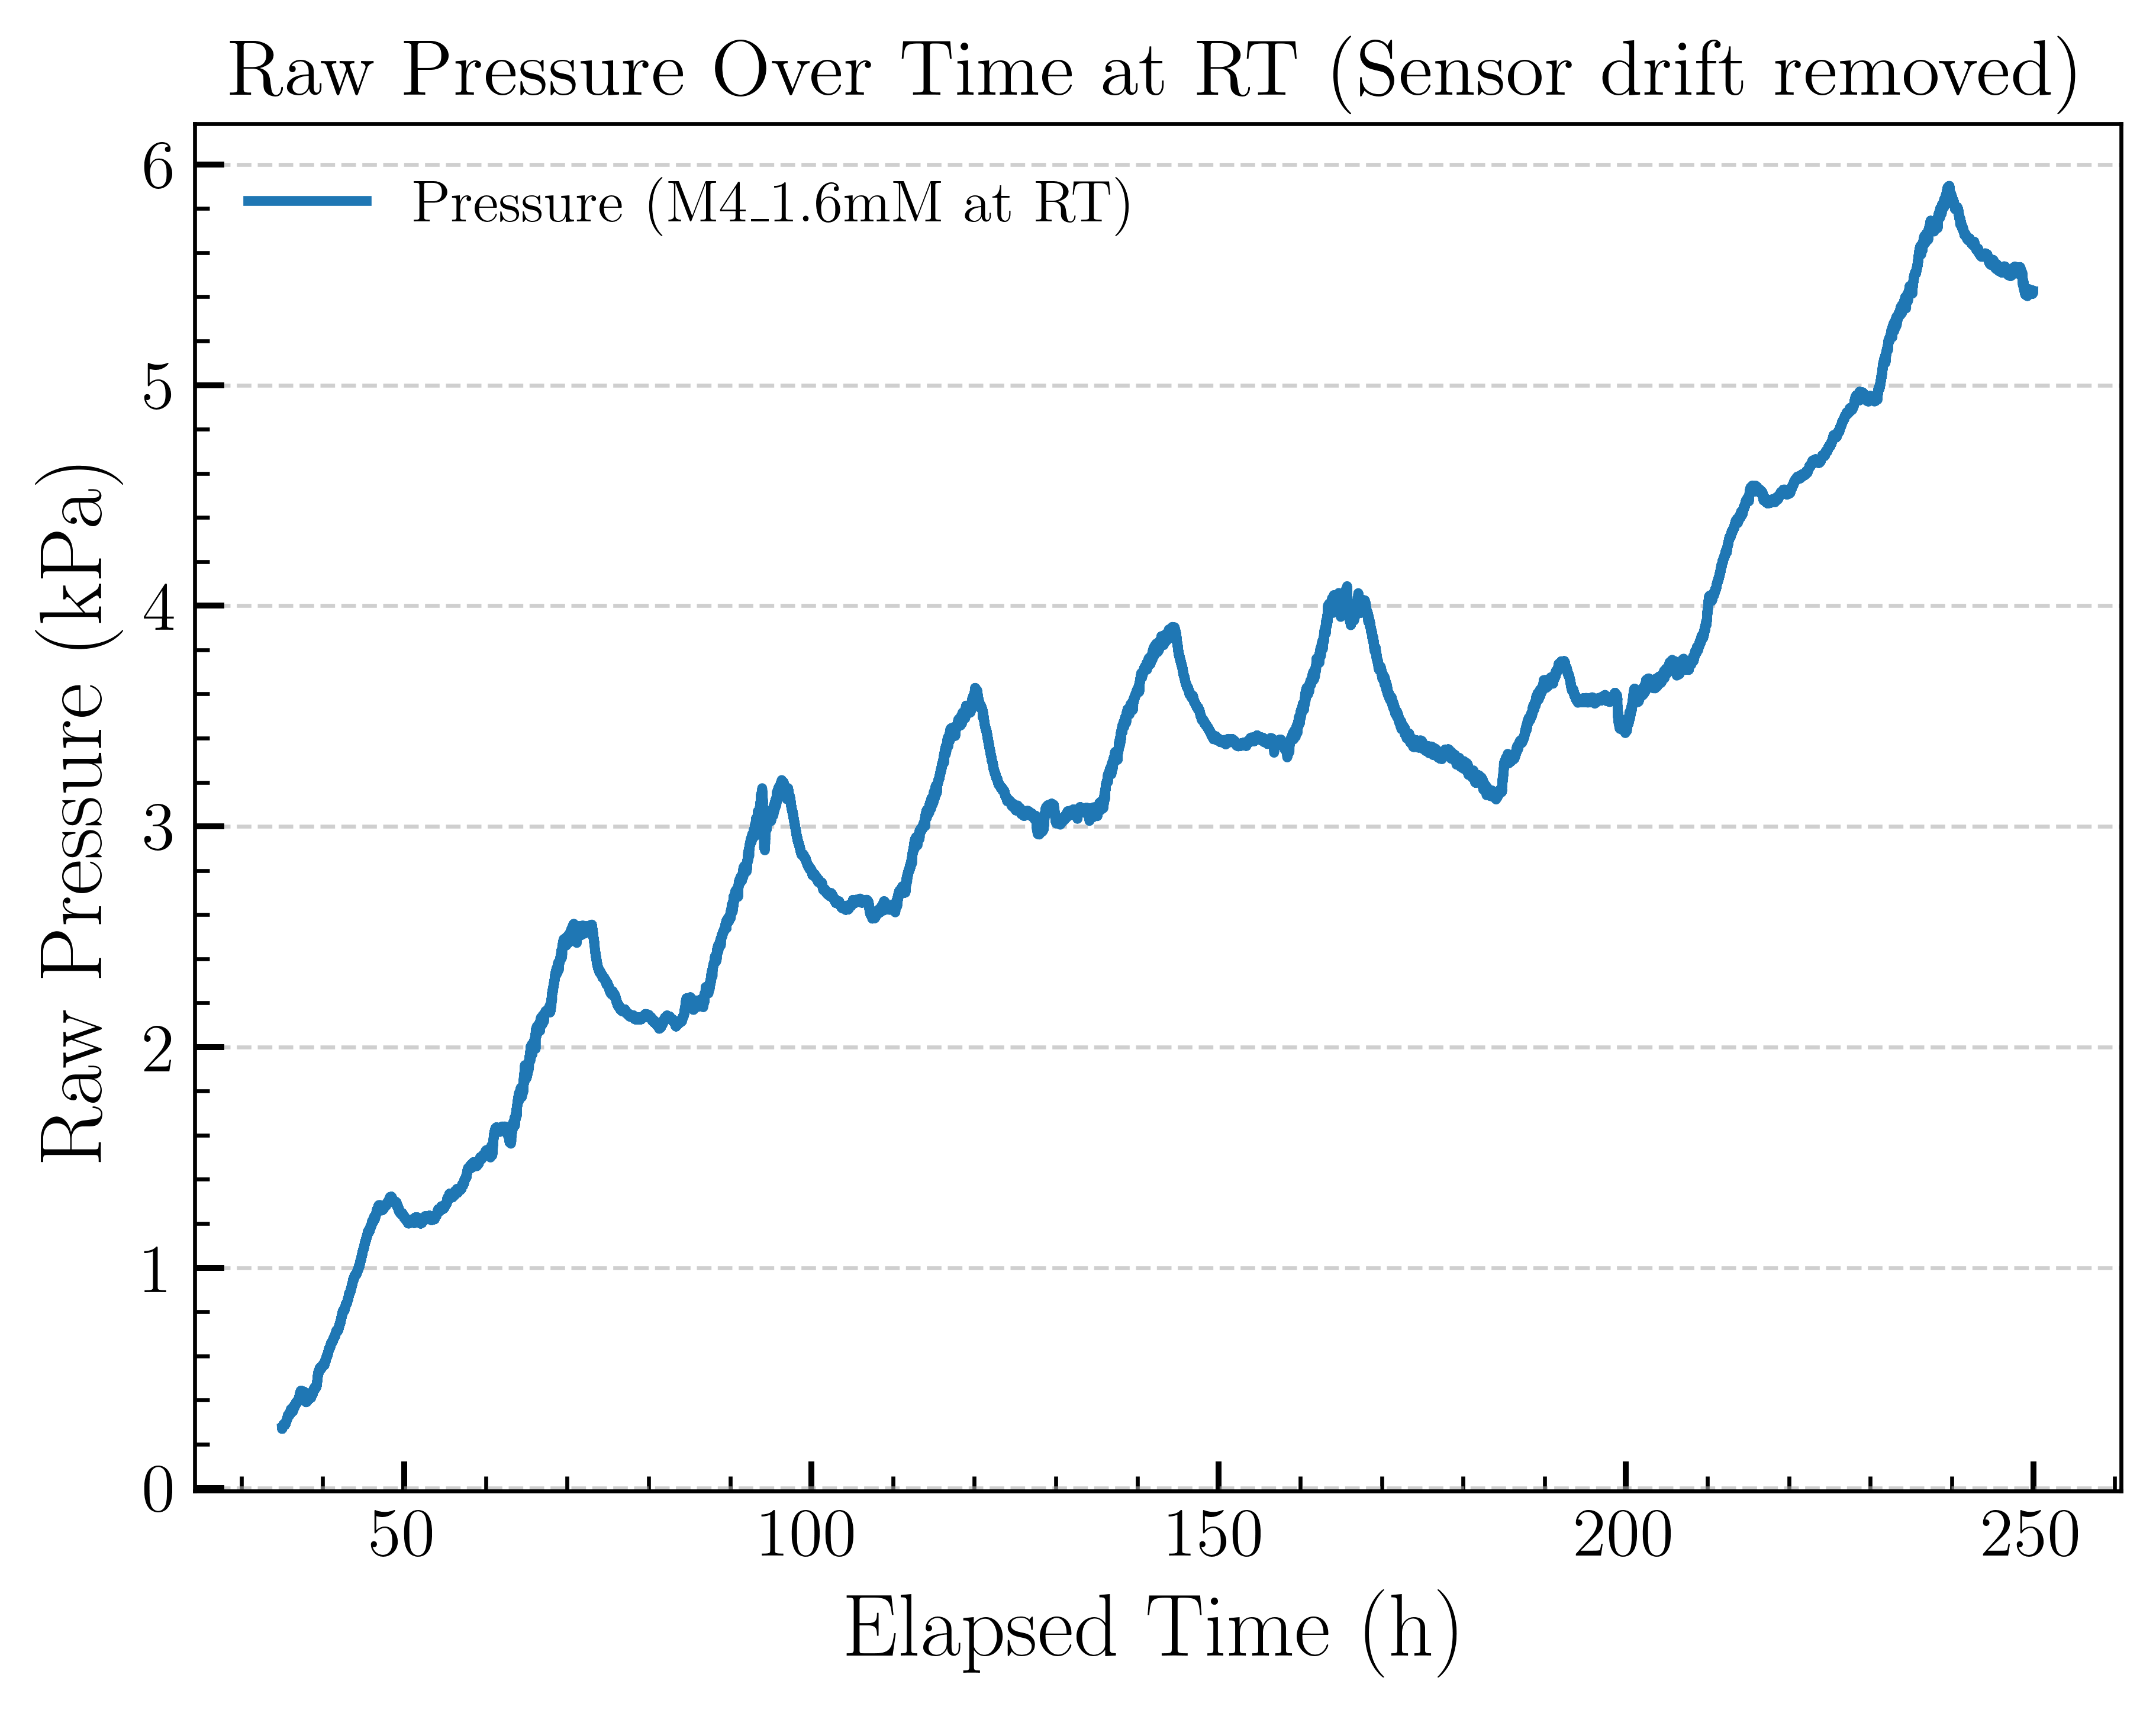

In [6]:
df_sensor = df[(df["Elapsed Time (hours)"] > 35) & (df["Elapsed Time (hours)"] <= 250)].reset_index(drop=True)




fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (Sensor drift removed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")

plt.show()

# For 35h, 8.7 umol max

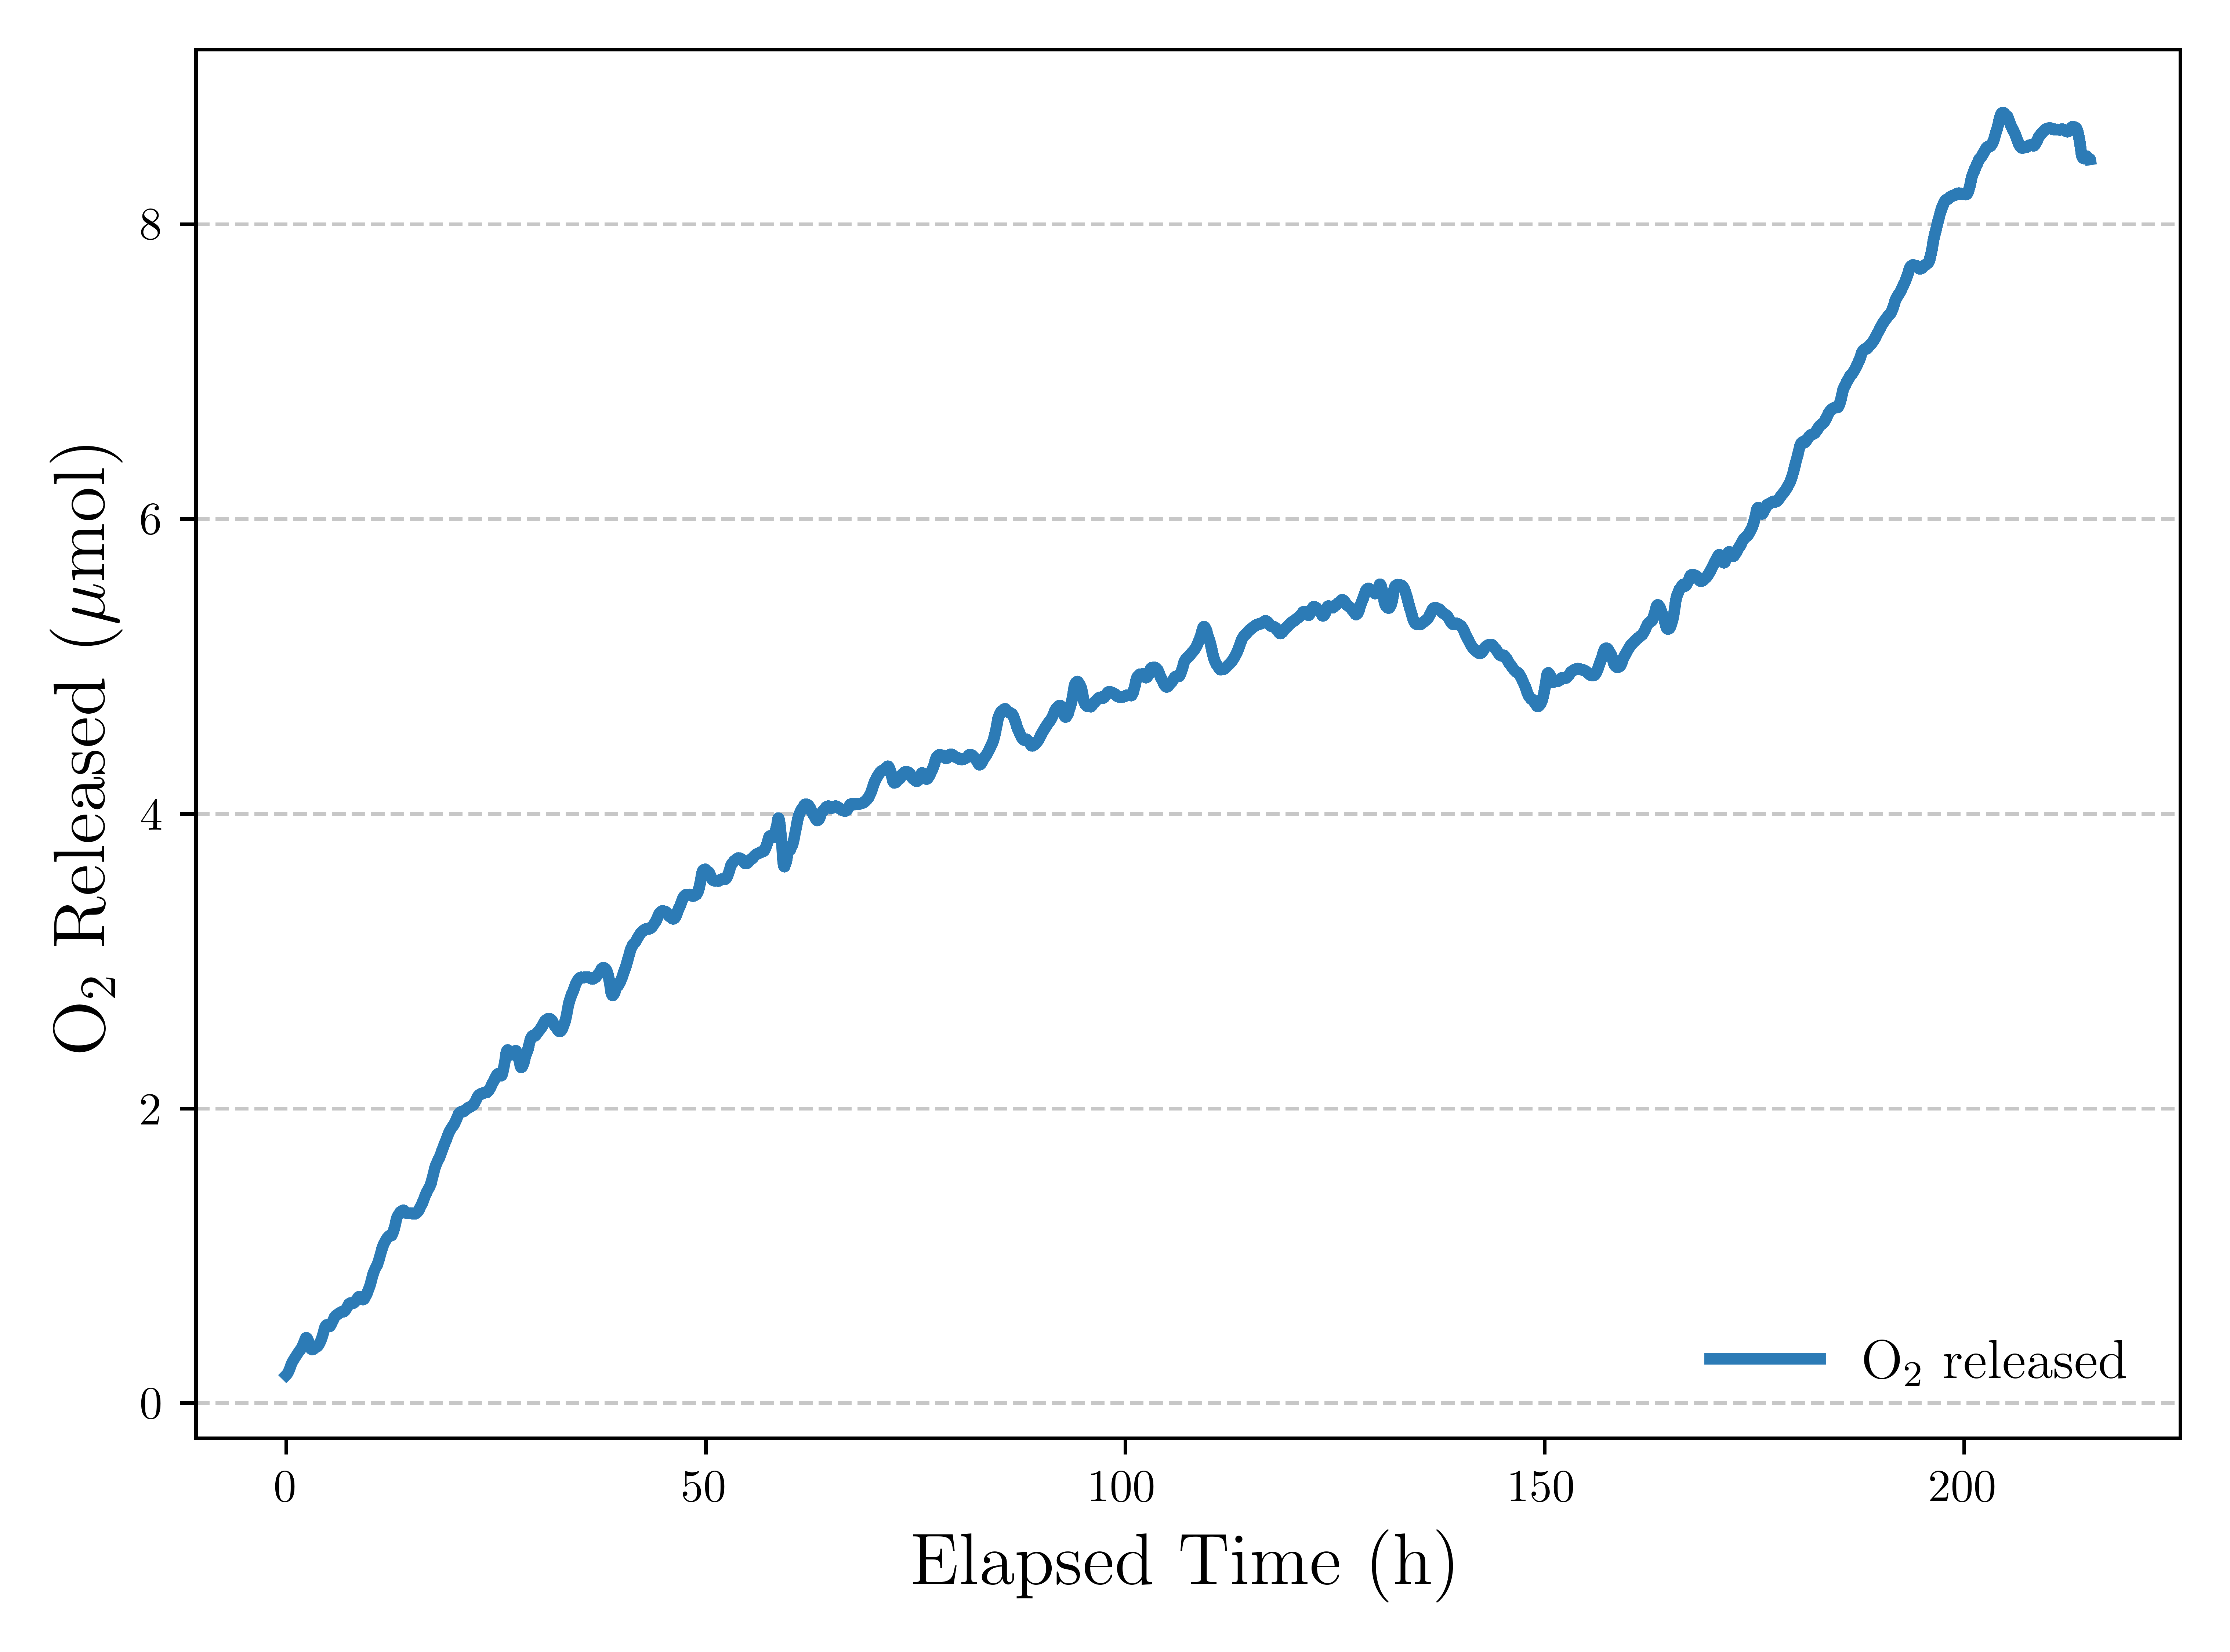

# Final selected 40h

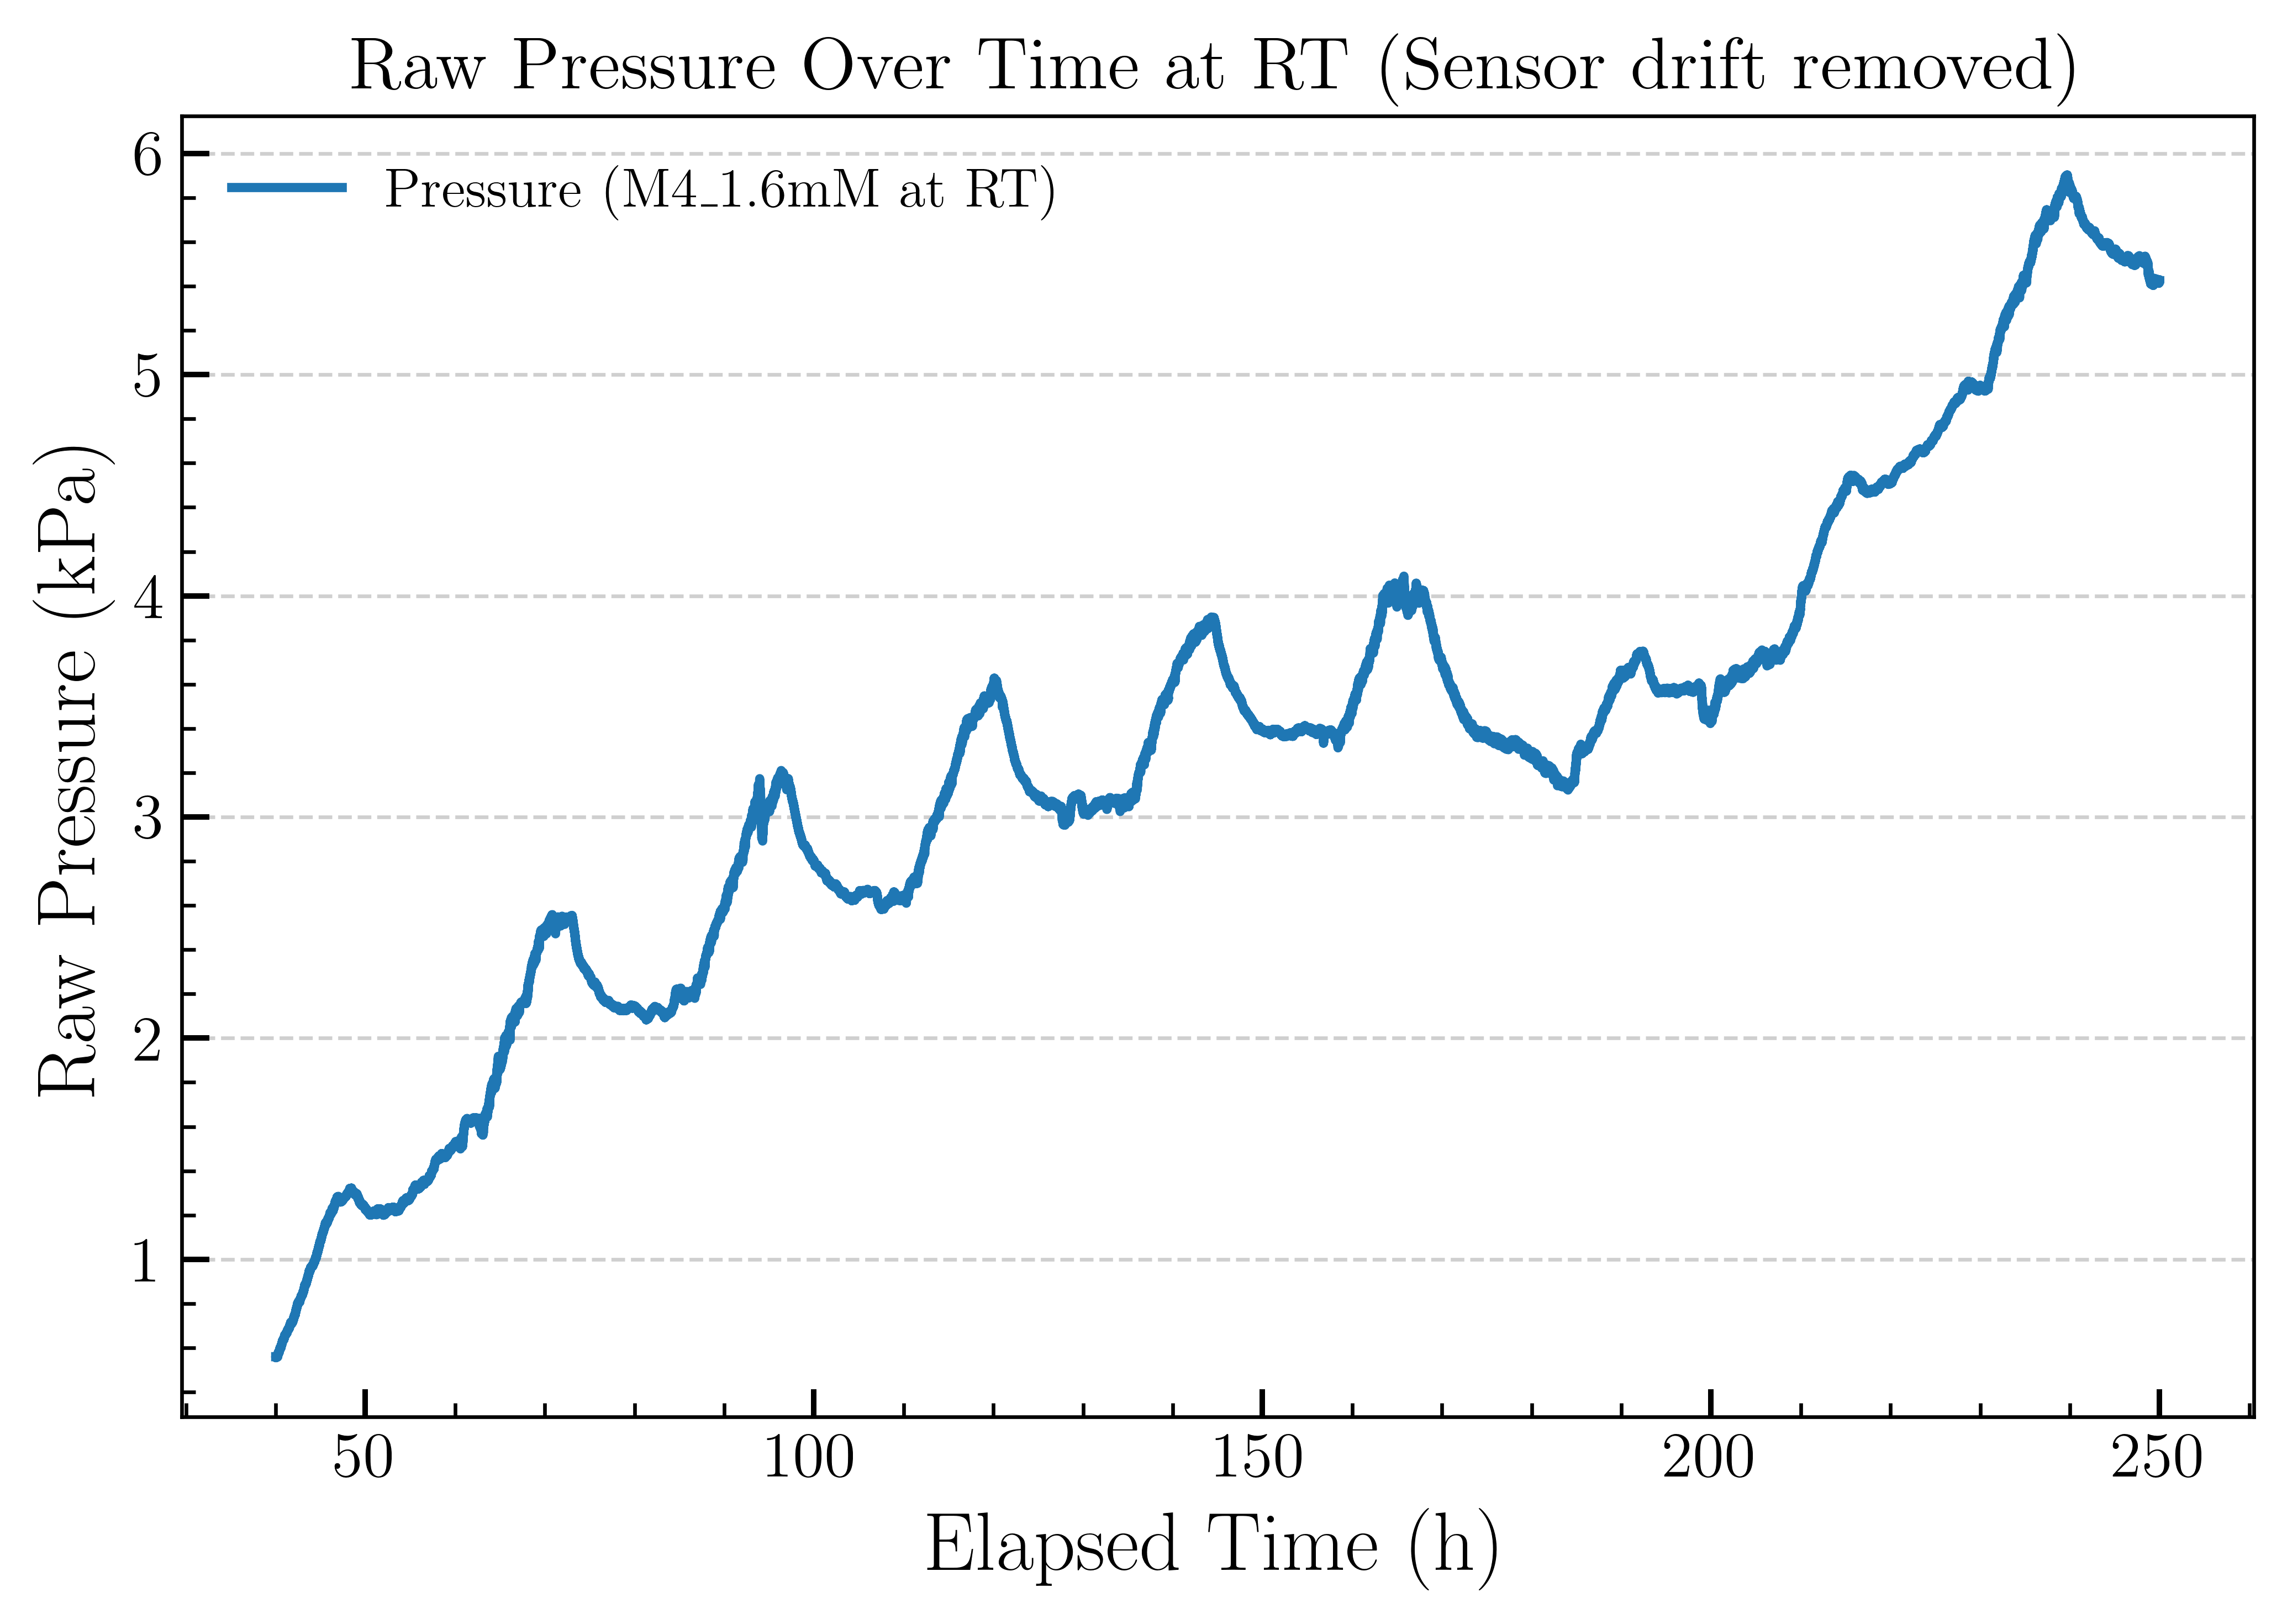

In [11]:
df_sensor = df[(df["Elapsed Time (hours)"] > 40) & (df["Elapsed Time (hours)"] <= 250)].reset_index(drop=True)

#6 hrs cropped


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_sensor["Elapsed Time (hours)"],
         df_sensor["ABP2-Sch1 (kPa)"],
         lw=2.0, color="tab:blue",
         label=r'Pressure (M4_1.6mM at RT)')

ax1.set_title('Raw Pressure Over Time at RT (Sensor drift removed)', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig('M4_1.6mM_RT_raw_pressure_sensor_drift_dropped.png', dpi=dpi, bbox_inches='tight')
plt.show()

Calculated Pressure Offset (from 40h to 41.5h): 0.6225 kPa


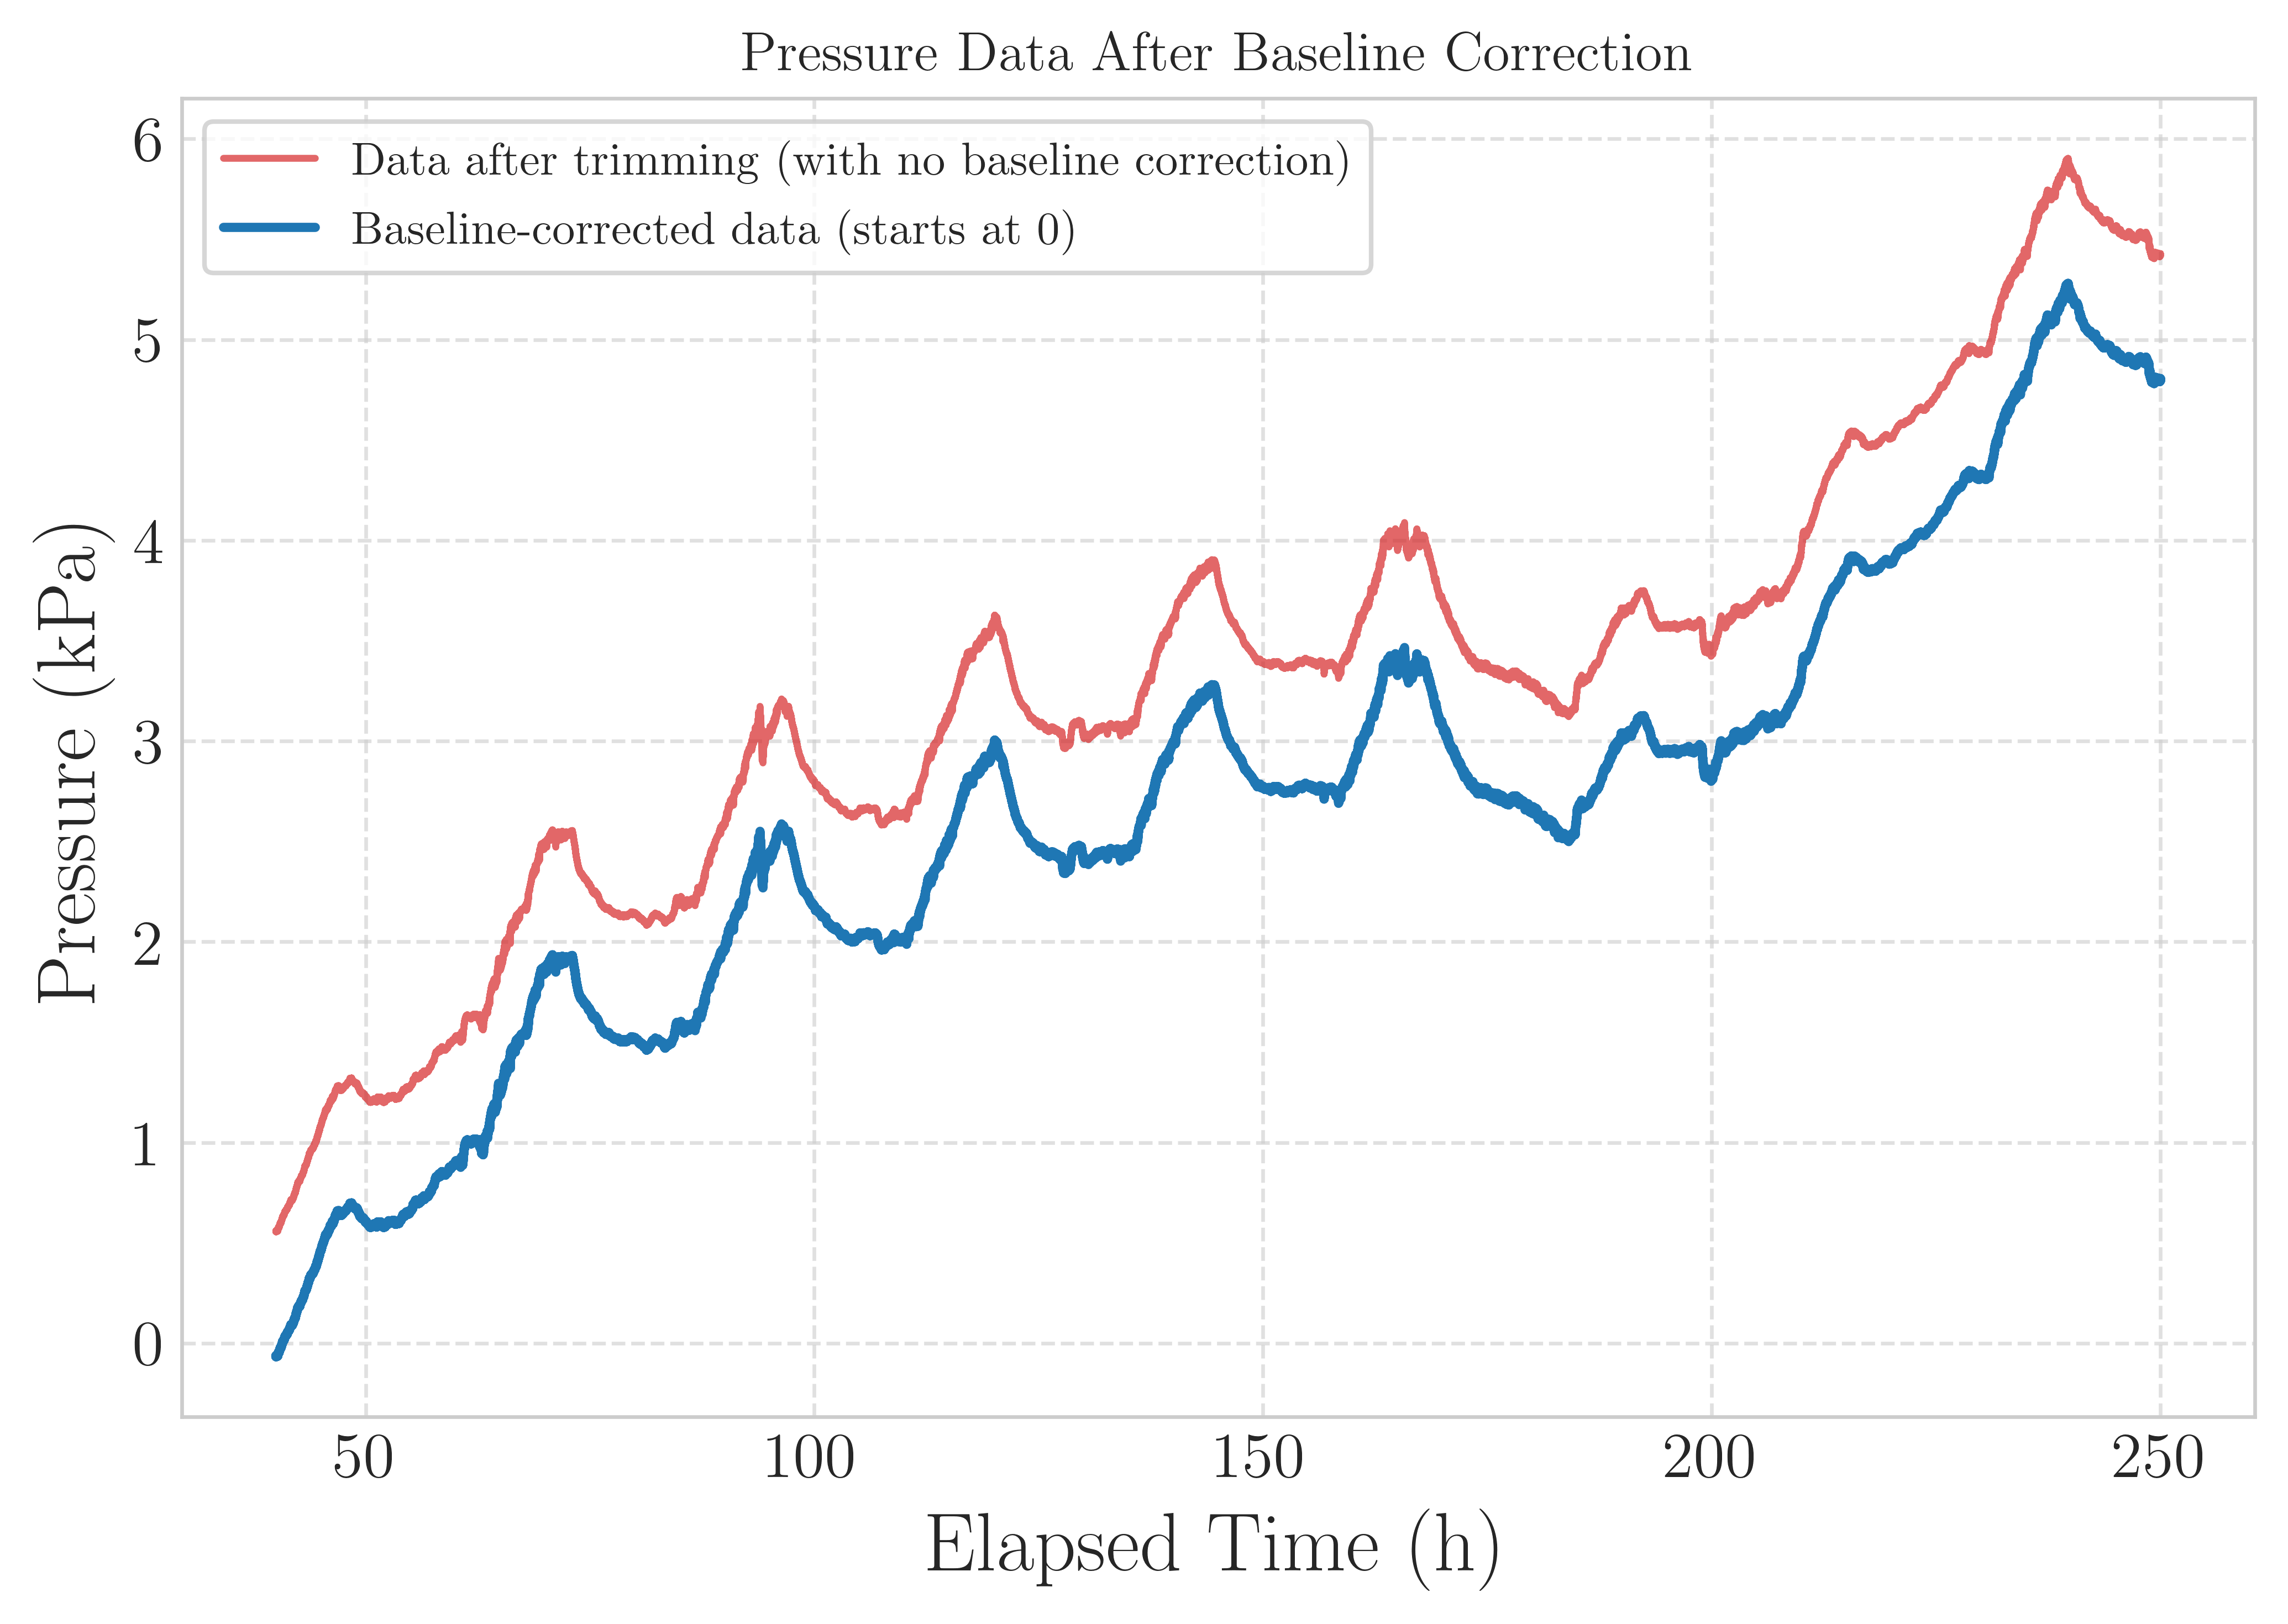

In [107]:
import pandas as pd
import matplotlib.pyplot as plt

# --- User-defined variables ---
# Use the path to your CSV file that has NOT been trimmed yet
main_path = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\RT\Raw_data\merged_pressure_log.csv"
time_col = "Elapsed Time (hours)"
pressure_col = "ABP2-Sch1 (kPa)"

# --- 1. Load and Trim the Data ---
df = pd.read_csv(main_path)
df_trimmed = df[(df[time_col] >= 40) & (df[time_col] <= 250)].reset_index(drop=True)


# --- 2. Perform Baseline Correction on the Trimmed Data ---
# Define the new baseline window (27h to 28.5h)
baseline_start = 40
baseline_end = 41.5

# Isolate the data within this new window
baseline_df = df_trimmed[(df_trimmed[time_col] >= baseline_start) & (df_trimmed[time_col] <= baseline_end)]

# Calculate the average offset from this period
pressure_offset = baseline_df[pressure_col].mean()
print(f"Calculated Pressure Offset (from {baseline_start}h to {baseline_end}h): {pressure_offset:.4f} kPa")

# Create a new column with the corrected pressure by subtracting the offset
corrected_pressure_col = 'Corrected Pressure (kPa)'
df_trimmed[corrected_pressure_col] = df_trimmed[pressure_col] - pressure_offset


fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(df_trimmed[time_col], df_trimmed[pressure_col], color="tab:red", alpha=0.7, label='Data after trimming (with no baseline correction)')
ax1.plot(df_trimmed[time_col], df_trimmed[corrected_pressure_col], color="tab:blue", lw=2.0, label='Baseline-corrected data (starts at 0)')
# ax1.plot(df_2["Elapsed Time (hours)"], df_2["ABP2-Sch1 (SPI1) Pressure (kPa)"], lw=2.0, color="tab:blue", label=r'Pressure with initial sensor noise M1-2.5mM at RT')

style_axes(ax1, xlabel="Elapsed Time (h)", ylabel=" Raw Pressure (kPa)", y_major=1.0)

ax1.set_title('Pressure Data After Baseline Correction')
ax1.set_xlabel("Elapsed Time (h)")
ax1.set_ylabel("Pressure (kPa)")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()
plt.tight_layout()
plt.savefig("M4_1.6mM_raw_vs_baseline_corrected.png", dpi=dpi, bbox_inches='tight')
plt.show()

In [51]:
pressure_atm  = 4.9 / 101.325


o2_micromol   = ((pressure_atm * 0.004) / (0.082057  * 297)) * 1e6

print(o2_micromol)


7.937200928054017


5.079629891509891
4.965898436178344


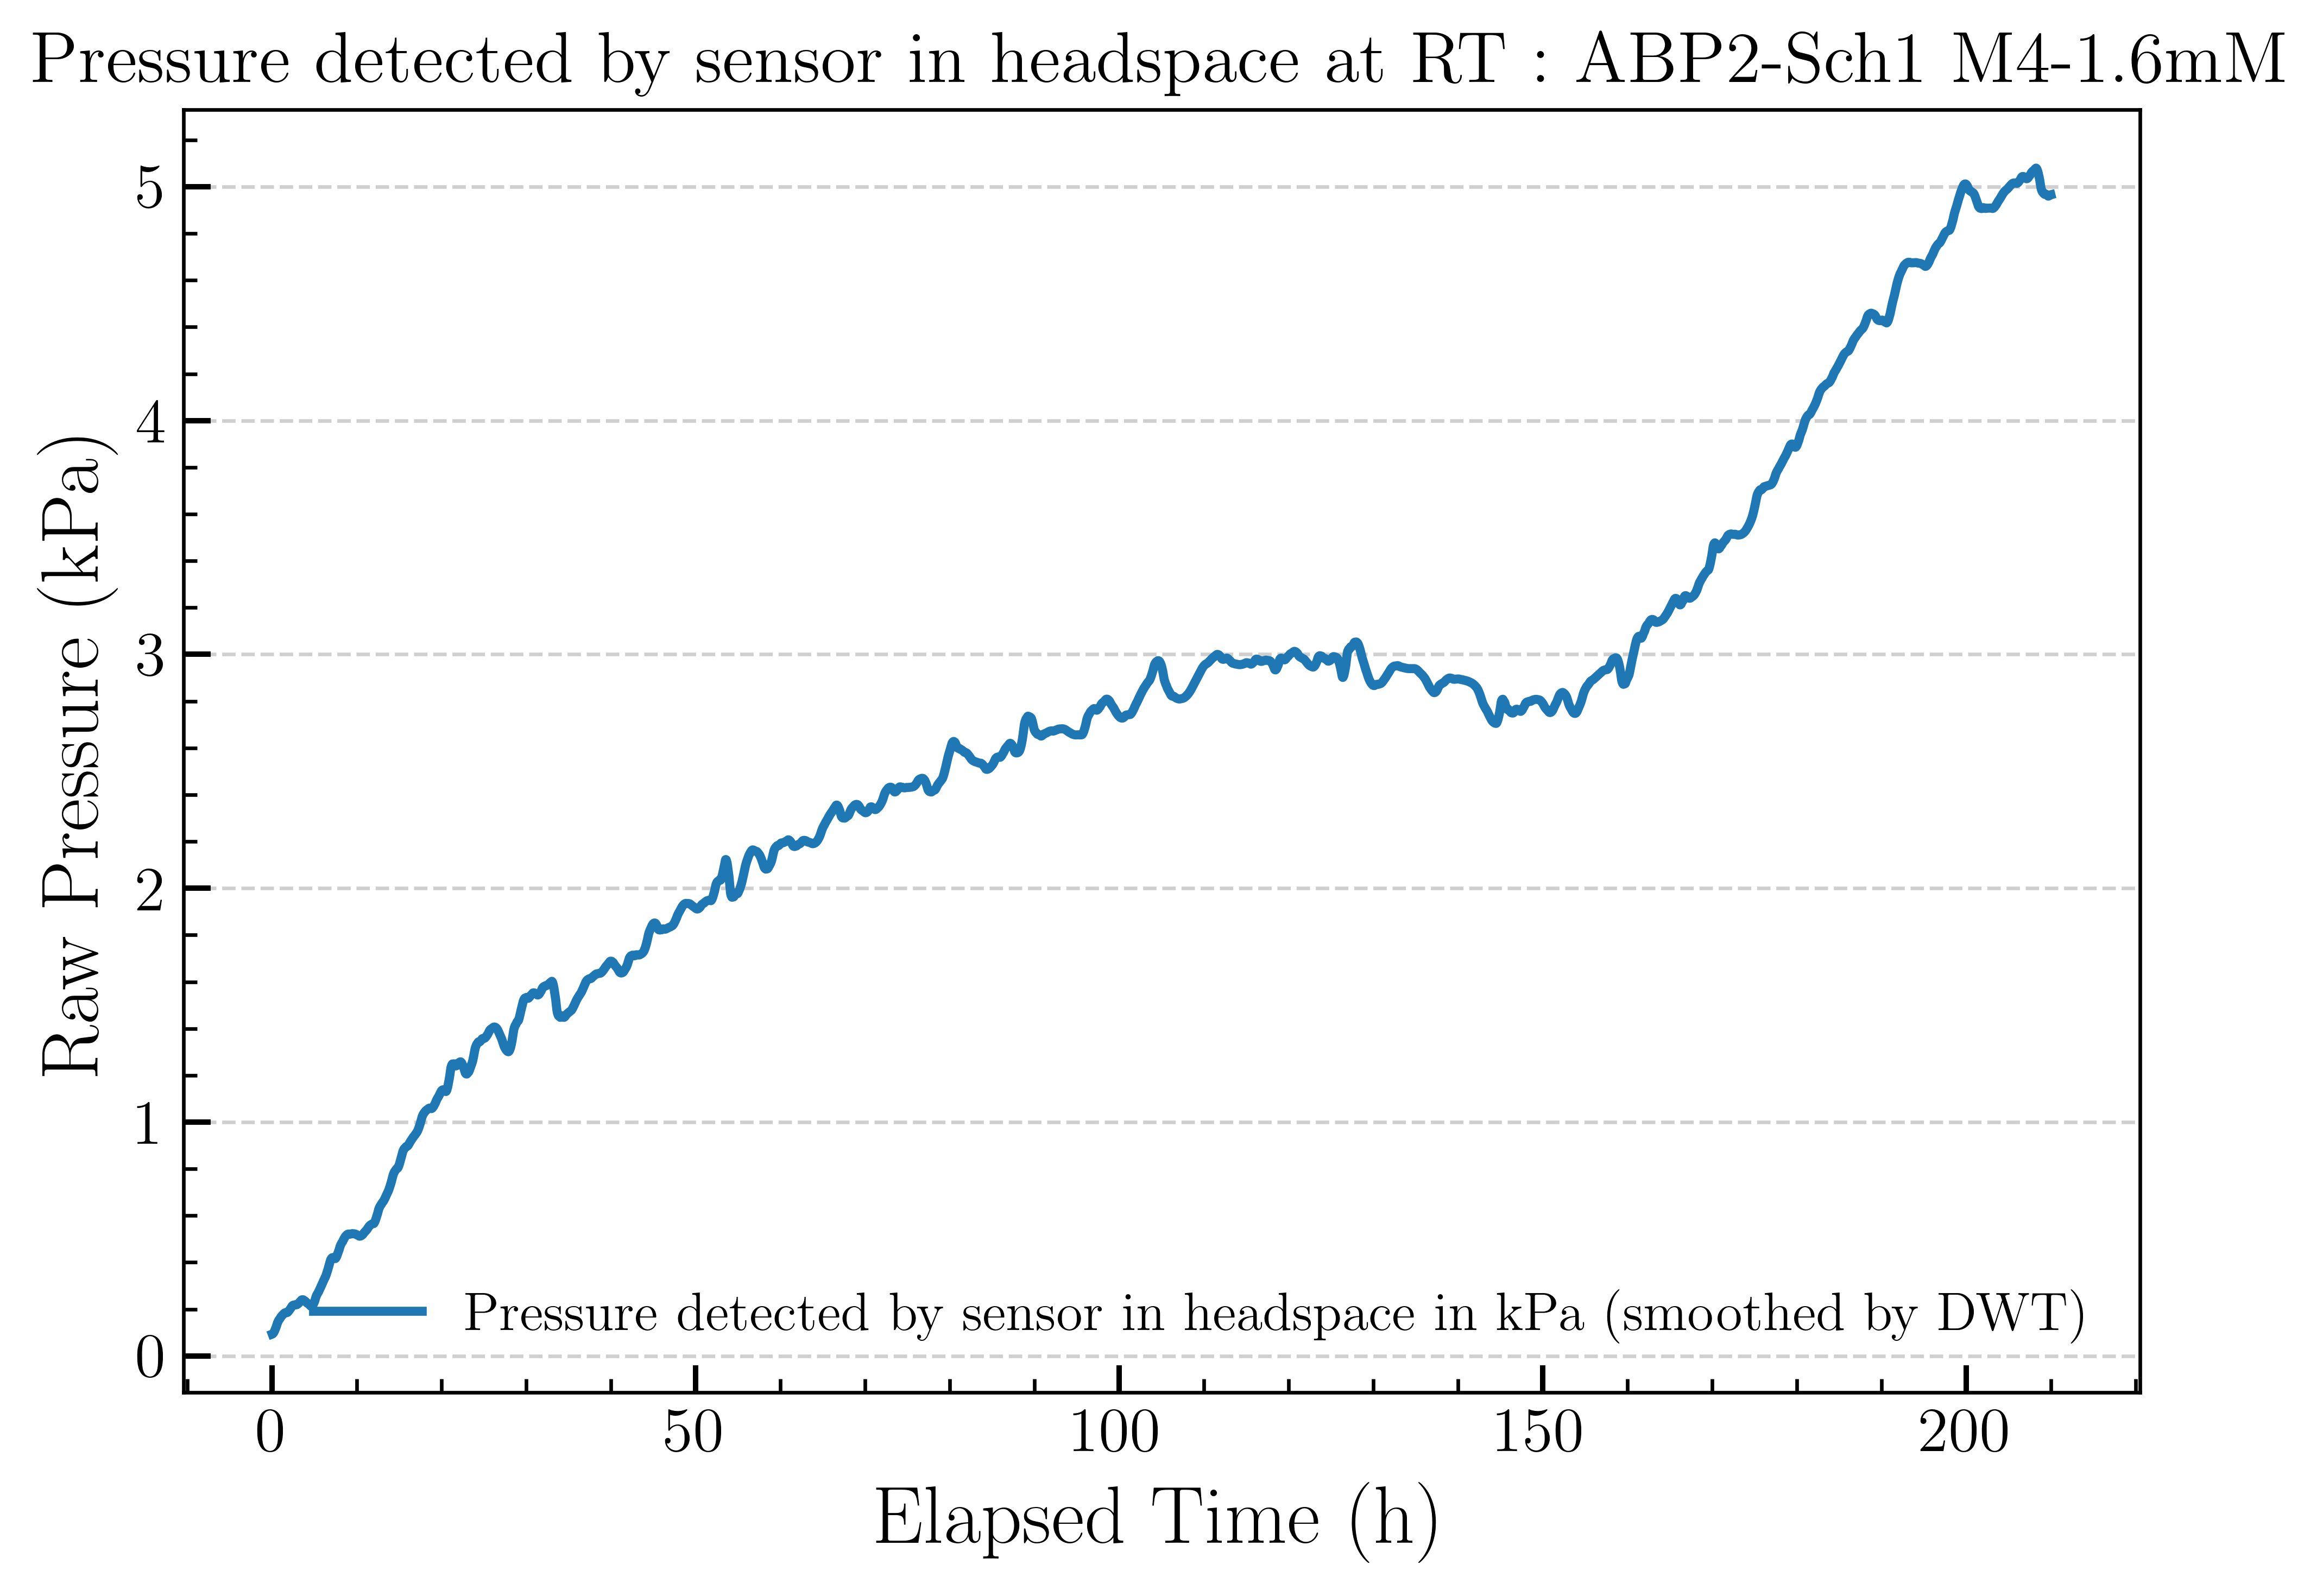

In [7]:


main = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\RT\denoised csv\M4_1.6mM_RT_pressure_o2_release.csv"

df_main = pd.read_csv(main)
df_main.columns = [c.strip() for c in df_main.columns]
df_main = df_main[df_main["Time (h)"] <= 250].reset_index(drop=True)


headspace_oxygen = df_main["DWT denoised pressure (kPa)"]
time_col = df_main["Time (h)"]

# df_sensor = df[df["Elnapsed Time (hours)"] > 0.5]



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(time_col,
         headspace_oxygen,
         lw=2.0, color="tab:blue",
         label=r'Pressure detected by sensor in headspace in kPa (smoothed by DWT)')

ax1.set_title('Pressure detected by sensor in headspace at RT : ABP2-Sch1 M4-1.6mM', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Raw Pressure (kPa)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig("M4_1.6mM_headspace_pressure.png", dpi=dpi, bbox_inches='tight')


print(max(headspace_oxygen))
print(headspace_oxygen.iloc[-1])












8.253964745632764
8.070575831092665


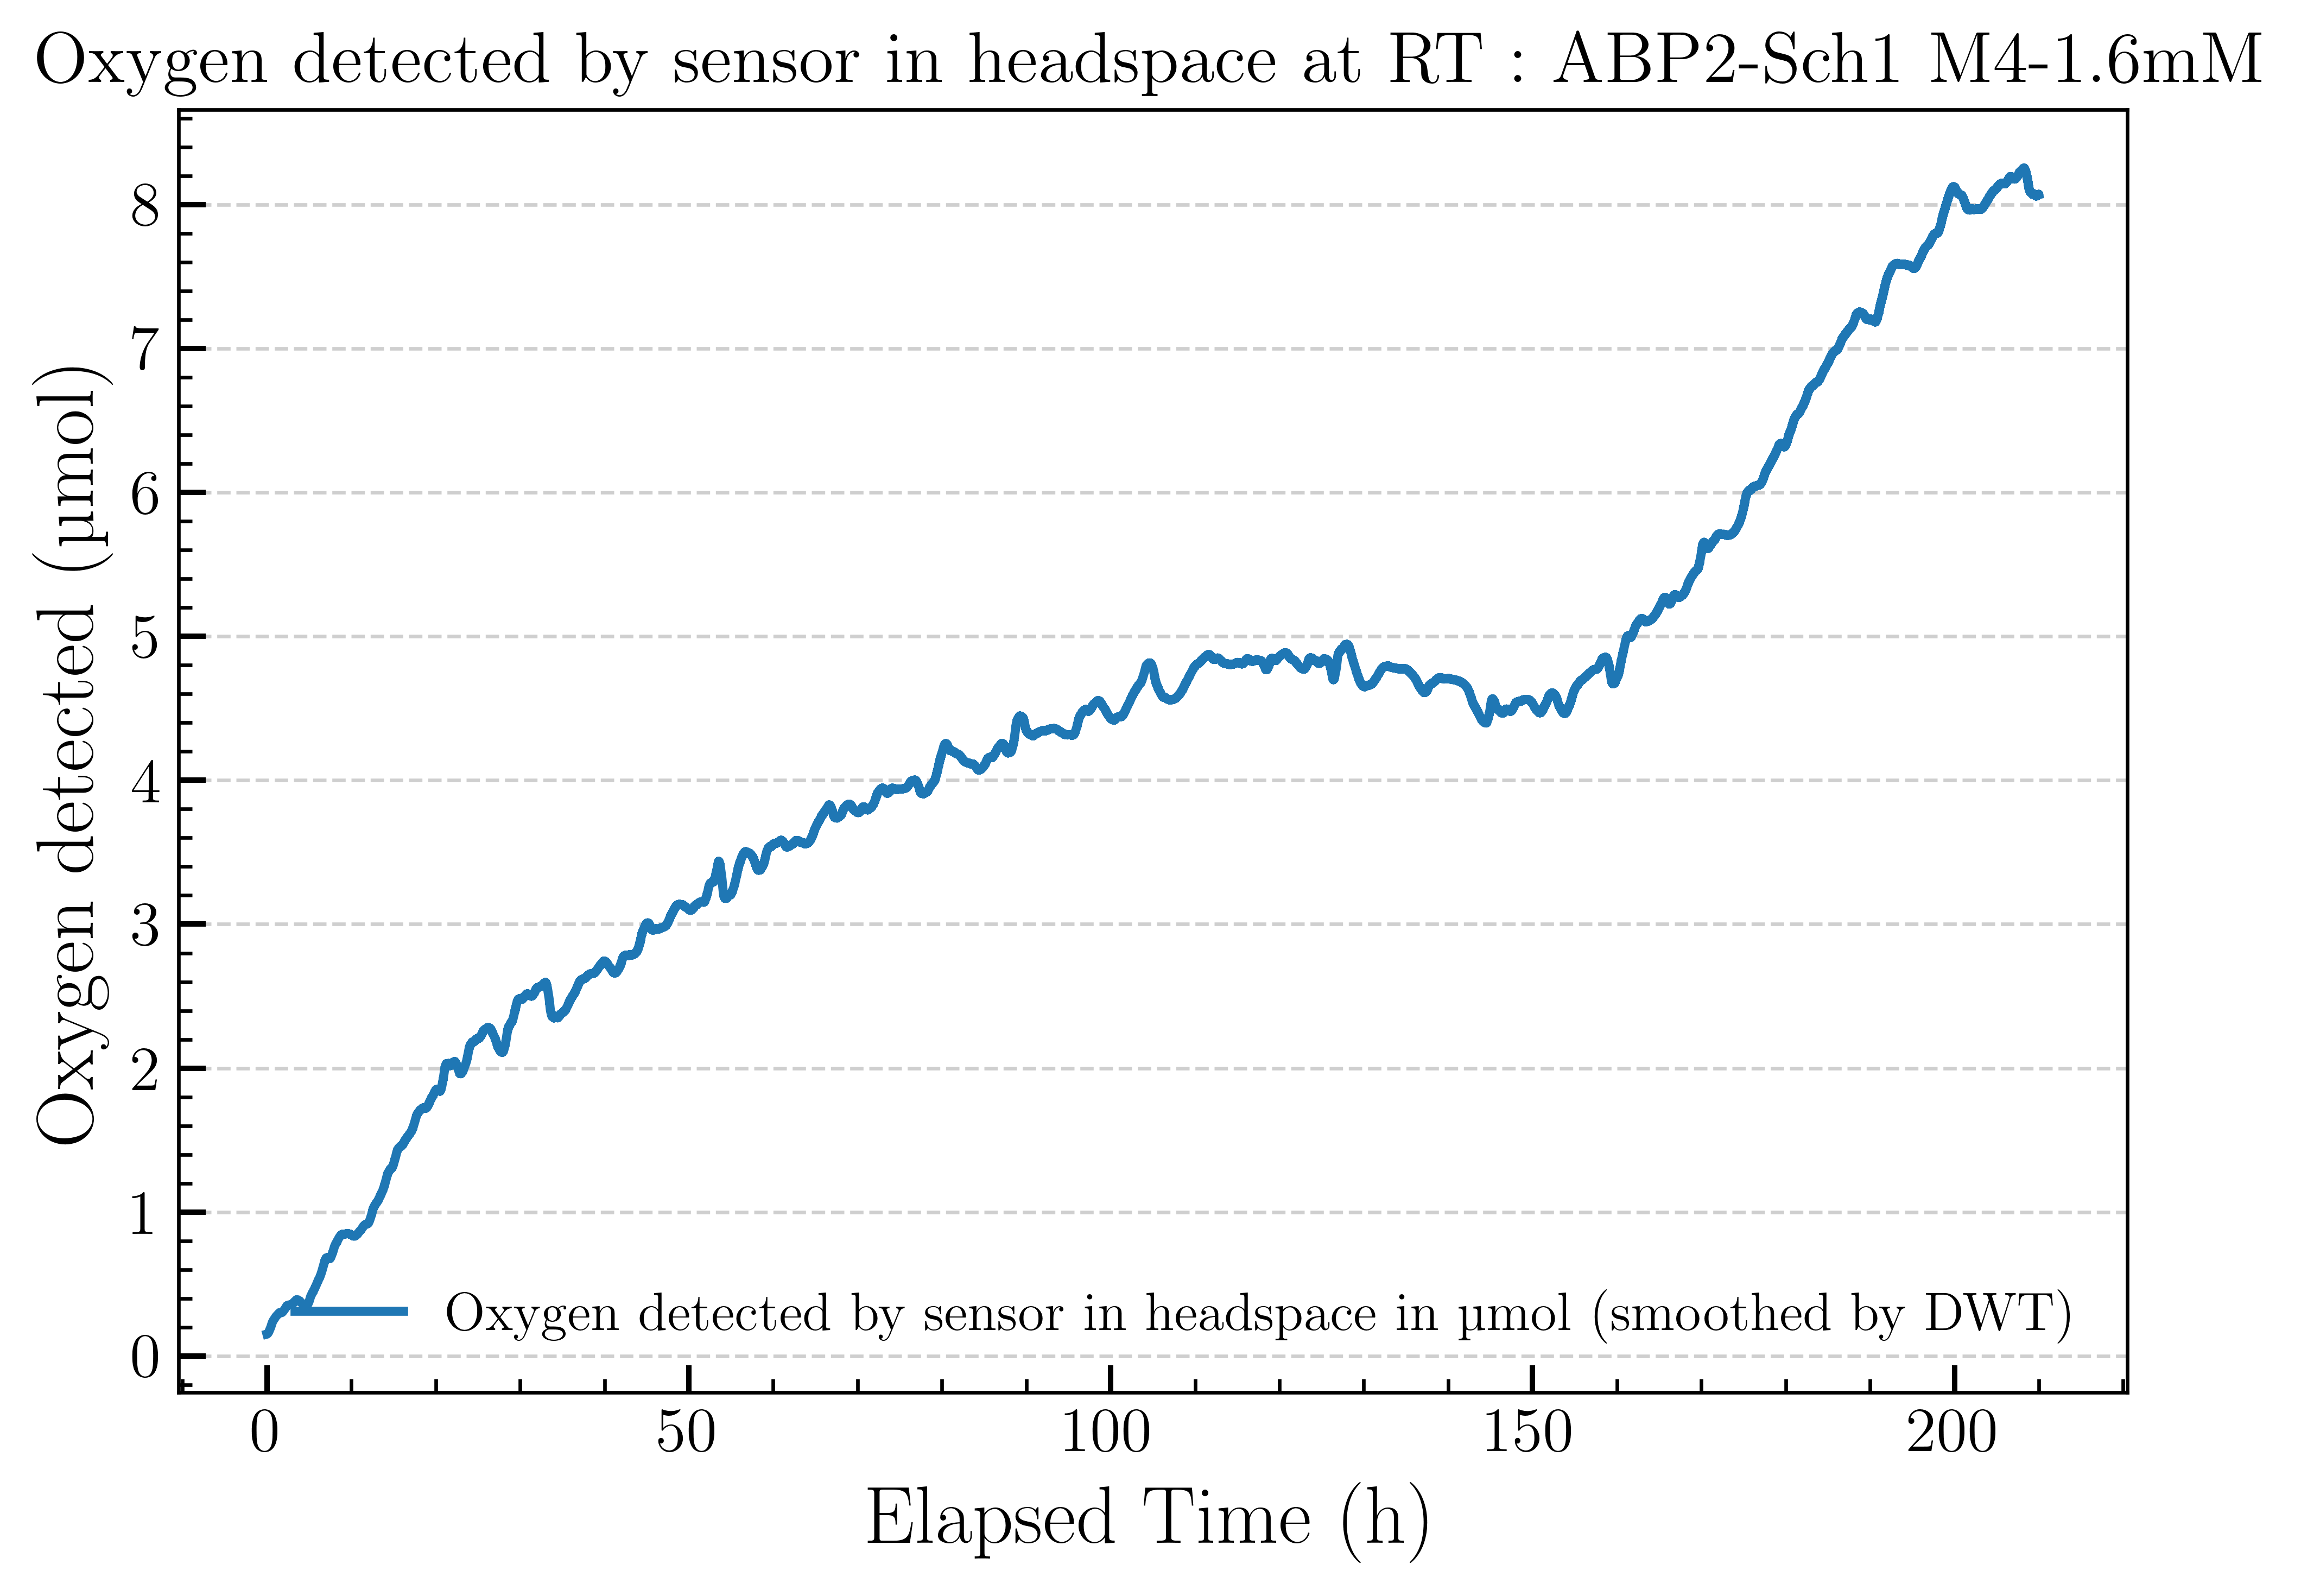

In [8]:


main = r"C:\Users\chand\Documents\GitHub\Thesis\M4-1.6 mM\RT\denoised csv\M4_1.6mM_RT_pressure_o2_release.csv"

df_main = pd.read_csv(main)
df_main.columns = [c.strip() for c in df_main.columns]
df_main = df_main[df_main["Time (h)"] <= 250].reset_index(drop=True)


headspace_oxygen = df_main["O2 Released (µmol)"]
time_col = df_main["Time (h)"]

# df_sensor = df[df["Elapsed Time (hours)"] > 0.5]



fig, ax1 = plt.subplots(figsize=(7,5), dpi=dpi)
ax1.plot(time_col,
         headspace_oxygen,
         lw=2.0, color="tab:blue",
         label=r'Oxygen detected by sensor in headspace in µmol (smoothed by DWT)')

ax1.set_title('Oxygen detected by sensor in headspace at RT : ABP2-Sch1 M4-1.6mM', fontsize=16)
style_axes(ax1, xlabel="Elapsed Time (h)", ylabel="Oxygen detected (µmol)", y_major=1.0)
ax1.legend(frameon=False, fontsize=12, loc="best")
plt.tight_layout()
plt.savefig("M4_1.6mM_headspace_oxygen.png", dpi=dpi, bbox_inches='tight')





print(max(headspace_oxygen))
print(headspace_oxygen.iloc[-1])